<a href="https://colab.research.google.com/github/DariaChernykh4/lviv-food-marketplace-intelligence/blob/main/notebooks/02_market_analysis/01_lviv_restaurant_market_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lviv Restaurant Market Intelligence**

### [**View Interactive Dashboard (Tableau Public)**](https://public.tableau.com/views/LvivRestaurantMarket/Market?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

## **1. Introduction**

The restaurant market in Lviv is highly diverse, ranging from traditional Ukrainian restaurants and cafes to international cuisine concepts, bakeries, coffee shops, and fast-food operators.

This project analyzes the competitive landscape of the Lviv restaurant market using data collected from Google Maps and enriched with additional features such as district classification, cuisine segmentation, business model categorization, delivery availability, and Bayesian Rating.

The objective is to understand the structure of the market, identify dominant segments, evaluate restaurant reputation patterns, assess delivery penetration, and uncover potential market opportunities.

### **Business Questions**

This analysis aims to answer the following questions:

- How large and diversified is the restaurant market in Lviv?
- Which cuisine categories dominate the market?
- How are restaurants distributed across city districts?
- Which business models are most common?
- How does restaurant quality vary across cuisines and districts?
- What is the relationship between ratings and review volume?
- How widespread are delivery services and Glovo presence?
- Which market segments appear saturated and which may offer growth opportunities?
- Where can new restaurant concepts potentially gain a competitive advantage?

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from datetime import datetime

from google.colab import drive

## **2. Data Loading**

In [2]:
# Mount Google Drive and navigate to the project folder

In [3]:
# Display and visualization settings

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

colors = [
    "#587032",
    "#f67227",
    "#e764a5",
    "#ffbcbb",
    "#f04639"
]

## **3. Dataset Overview**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934 entries, 0 to 933
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   place_id                    934 non-null    object 
 1   found_name                  934 non-null    object 
 2   address                     934 non-null    object 
 3   latitude                    934 non-null    float64
 4   longitude                   934 non-null    float64
 5   district                    934 non-null    object 
 6   rating                      861 non-null    float64
 7   reviews_count               934 non-null    float64
 8   has_rating                  934 non-null    bool   
 9   bayesian_rating             861 non-null    float64
 10  price_level                 934 non-null    object 
 11  business_model              934 non-null    object 
 12  cuisine_type                934 non-null    object 
 13  standard_opening_hours      848 non

In [5]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# Column types

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns
bool_cols = df.select_dtypes(include="bool").columns

print(f"\nNumeric columns ({len(num_cols)}): {list(num_cols)}")
print(f"Categorical columns ({len(cat_cols)}): {list(cat_cols)}")
print(f"Boolean columns ({len(bool_cols)}): {list(bool_cols)}")

Rows: 934
Columns: 22

Numeric columns (5): ['latitude', 'longitude', 'rating', 'reviews_count', 'bayesian_rating']
Categorical columns (12): ['place_id', 'found_name', 'address', 'district', 'price_level', 'business_model', 'cuisine_type', 'standard_opening_hours', 'different_schedule_details', 'closed_days', 'wheelchair', 'maps_url']
Boolean columns (5): ['has_rating', 'delivery', 'takeout', 'dine_in', 'glovo_available']


**Dataset Structure**

The dataset contains **934 unique restaurants** described by **22 variables** covering location, cuisine type, business model, customer ratings, operating characteristics, and service availability.

The data includes a combination of numerical, categorical, and boolean features, allowing the market to be analyzed from multiple perspectives including geography, customer reputation, restaurant positioning, and delivery adoption.

In [6]:
# Missing values summary

missing = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
      .query("missing_count > 0")
      .sort_values("missing_pct", ascending=False)
      .round(2)
)

missing

,missing_count,missing_pct
closed_days,841,90.04
different_schedule_details,696,74.52
wheelchair,578,61.88
standard_opening_hours,86,9.21
bayesian_rating,73,7.82
rating,73,7.82


In [7]:
# Duplicate checks

print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate place IDs: {df["place_id"].duplicated().sum()}")

Duplicate rows: 0
Duplicate place IDs: 0


**Data Quality Assessment**

The dataset demonstrates a high level of overall quality. No duplicate records or duplicate Google Maps place identifiers were detected, confirming that each observation represents a unique restaurant.

A detailed data quality review was performed during the dataset preparation stage to determine whether missing values represented actual data issues or expected limitations of the source systems.

Key findings include:

- **Closed days (90.0%)** and **different schedule details (74.5%)** are missing primarily because most restaurants operate on a consistent weekly schedule. In these cases, the absence of data indicates that no special schedule information is required rather than missing business information.

- **Wheelchair accessibility (61.9%)** is sparsely populated because Google Maps does not consistently collect accessibility data. These values were intentionally left as missing to avoid introducing assumptions about accessibility status.

- **Standard opening hours (9.2%)** are unavailable for a small subset of restaurants where operating hours were not provided by Google Maps.

- **Rating (7.8%)** and **Bayesian Rating (7.8%)** are missing exclusively for restaurants without customer reviews. These establishments were retained because they still represent active market participants and contribute to overall market structure.

Additional validation rules were applied during dataset preparation to ensure logical consistency between business models and service attributes. For example, delivery-only kitchens cannot offer dine-in service, while restaurants classified as delivery-enabled must have delivery available.

As a result, the final dataset represents a cleaned, validated, and internally consistent view of the Lviv restaurant market suitable for competitive and market intelligence analysis.

In [8]:
# Market overview metrics

market_overview = pd.DataFrame({
    "metric": [
        "Restaurants",
        "Districts",
        "Cuisine types",
        "Business models",
        "Average rating",
        "Median rating",
        "Average Bayesian rating",
        "Average reviews per restaurant",
        "Restaurants with delivery",
        "Restaurants available on Glovo"
    ],
    "value": [
        f"{df["place_id"].nunique():,}",
        f"{df["district"].nunique():,}",
        f"{df["cuisine_type"].nunique():,}",
        f"{df["business_model"].nunique():,}",
        f"{df["rating"].mean():.2f}",
        f"{df["rating"].median():.2f}",
        f"{df["bayesian_rating"].mean():.2f}",
        f"{df["reviews_count"].mean():,.0f}",
        f"{df["delivery"].mean() * 100:.1f}%",
        f"{df["glovo_available"].mean() * 100:.1f}%"
    ]
})

market_overview

,metric,value
0,Restaurants,934
1,Districts,6
2,Cuisine types,46
3,Business models,8
4,Average rating,4.35
5,Median rating,4.50
6,Average Bayesian rating,4.36
7,Average reviews per restaurant,554
8,Restaurants with delivery,67.1%
9,Restaurants available on Glovo,26.8%


**Market Overview**

The dataset captures a large and diverse restaurant market consisting of **934 restaurants**, **46 cuisine categories**, and **8 business model types** across all major districts of Lviv.

Customer reputation across the market is generally strong, with an average rating of **4.35** and an average Bayesian Rating of **4.36**. Restaurants also demonstrate substantial customer engagement, averaging more than **500 reviews per establishment**.

Delivery has become a standard service offering, with approximately **two-thirds of restaurants** providing delivery options. At the same time, only around **one quarter of restaurants** are currently present on Glovo, indicating that a significant share of delivery activity occurs through alternative platforms or direct ordering channels.

These metrics suggest a mature and competitive restaurant ecosystem with a broad range of concepts, cuisines, and customer acquisition strategies. The gap between **delivery adoption (67%)** and **Glovo presence (27%)** already signals that marketplace penetration will be a recurring theme throughout this analysis.

## **4. Market Structure**

### **4.1. Business Model Summary**

In [9]:
# Business model summary

business_model_summary = df["business_model"].value_counts().to_frame("restaurants")

business_model_summary["share_pct"] = (
    business_model_summary["restaurants"] / len(df) * 100
).round(2)

business_model_summary

,restaurants,share_pct
business_model,,
Restaurant with Delivery,406,43.47
Dine-in Restaurant,125,13.38
Delivery Only / Dark Kitchen,105,11.24
Cafe,91,9.74
Bakery,71,7.60
Takeaway Spot,56,6.00
Restaurant,53,5.67
Hotel Restaurant,27,2.89


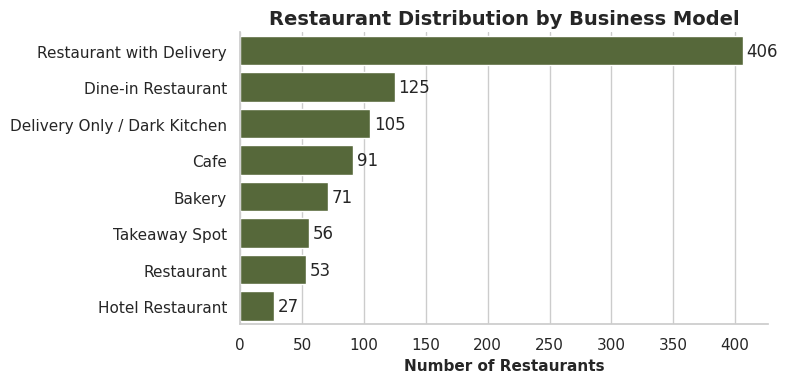

In [10]:
# Business model distribution

business_model = df["business_model"].value_counts()

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=business_model.values,
    y=business_model.index,
    color=colors[0]
)

for i, v in enumerate(business_model.values):
    ax.text(v + 3, i, v, va="center")

plt.title("Restaurant Distribution by Business Model", fontsize=14, fontweight="bold")
plt.xlabel("Number of Restaurants", fontsize=11, fontweight="bold")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

**Business Model Findings**

The Lviv restaurant market is strongly oriented toward delivery-enabled operations.

**Restaurant with Delivery** is the dominant business model, representing **43.5%** of all restaurants in the dataset. This suggests that delivery has evolved from a supplementary service into a core component of restaurant operations.

Traditional **Dine-in Restaurants** account for **13.4%** of establishments, while **Delivery Only / Dark Kitchens** represent **11.2%**. Combined, these two segments account for nearly one-quarter of the market, highlighting the importance of both on-premise dining and delivery-focused concepts.

The remaining market is distributed across cafes, bakeries, takeaway operators, and hotel restaurants. Although individually smaller, these formats contribute to the diversity of the local food service ecosystem and address different customer needs and consumption occasions.

Overall, the business model distribution reflects a mature and competitive market where delivery capabilities play a significant role in restaurant positioning and customer acquisition.

### **4.2. Service Availability**



In [11]:
# Service availability summary

service_summary = pd.DataFrame({
    "restaurants": df[["delivery", "takeout", "dine_in", "glovo_available"]].sum()
})

service_summary["share_pct"] = (
    service_summary["restaurants"] / len(df) * 100
).round(2)

service_summary.sort_values("share_pct", ascending=False)

,restaurants,share_pct
takeout,813,87.04
dine_in,671,71.84
delivery,627,67.13
glovo_available,250,26.77


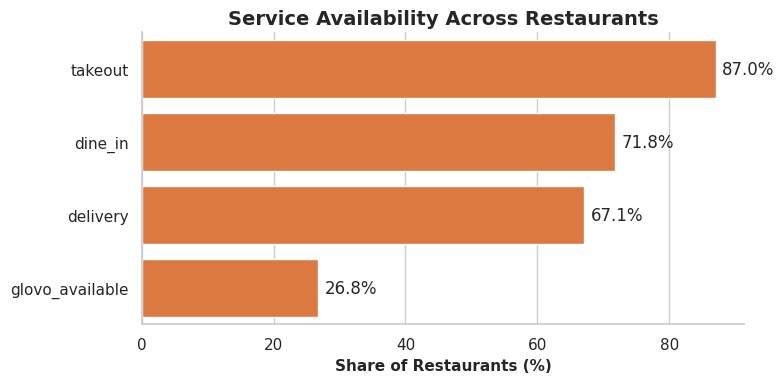

In [12]:
# Service availability

service = (
    df[["delivery", "takeout", "dine_in", "glovo_available"]]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=service.values,
    y=service.index,
    color=colors[1]
)

for i, v in enumerate(service.values):
    ax.text(v + 1, i, f"{v:.1f}%", va="center")

plt.title("Service Availability Across Restaurants", fontsize=14, fontweight="bold")
plt.xlabel("Share of Restaurants (%)", fontsize=11, fontweight="bold")
plt.ylabel("", fontsize=11, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

**Service Availability Findings**

Takeout is the most widely adopted service in the Lviv restaurant market, offered by **87.0%** of restaurants. This indicates that most establishments are equipped to serve customers beyond traditional dine-in experiences.

**71.8%** of restaurants provide dine-in service, while **67.1%** offer delivery. The relatively small gap between these two metrics suggests that delivery has become a mainstream operating model rather than a niche service limited to specific restaurant formats.

The most notable finding is the gap between overall delivery availability and marketplace presence. While more than two-thirds of restaurants offer delivery, only **26.8%** are available on Glovo.

This suggests that a substantial share of restaurants either rely on alternative delivery platforms, operate their own delivery channels, or provide delivery services that are not integrated with major marketplace aggregators.

Overall, the results highlight the importance of omnichannel service models in the Lviv restaurant market and indicate that marketplace penetration remains significantly lower than overall delivery adoption.

### **4.3. Operating Hours and Weekly Availability**

In [13]:
# 24/7 restaurants based on standard opening hours

df["is_24_7"] = df["standard_opening_hours"].astype(str).str.contains(
    "00:00 - 23:59|24 hours|Open 24 hours",
    case=False,
    regex=True
)

In [14]:
# Operating hours availability summary

hours_summary = pd.DataFrame({
    "restaurants": [
        df["standard_opening_hours"].notna().sum(),
        df["different_schedule_details"].notna().sum(),
        df["closed_days"].notna().sum(),
        df["is_24_7"].sum()
    ],
    "share_pct": [
        df["standard_opening_hours"].notna().mean() * 100,
        df["different_schedule_details"].notna().mean() * 100,
        df["closed_days"].notna().mean() * 100,
        df["is_24_7"].mean() * 100
    ]
}, index=[
    "Standard opening hours available",
    "Different schedule details available",
    "Closed days specified",
    "24/7 restaurants"
]).round(2)

hours_summary

,restaurants,share_pct
Standard opening hours available,848,90.79
Different schedule details available,238,25.48
Closed days specified,93,9.96
24/7 restaurants,37,3.96


In [15]:
# Closed days analysis

closed_days_exploded = (
    df[df["closed_days"].notna()]
    .assign(closed_day=df["closed_days"].str.split(", "))
    .explode("closed_day")
)

closed_days_summary = closed_days_exploded["closed_day"].value_counts().to_frame("restaurants")

closed_days_summary["share_of_all_restaurants_pct"] = (
    closed_days_summary["restaurants"] / len(df) * 100
).round(2)

closed_days_summary

,restaurants,share_of_all_restaurants_pct
closed_day,,
Sunday,74,7.92
Saturday,54,5.78
Monday,19,2.03
Tuesday,7,0.75
Wednesday,6,0.64
Thursday,3,0.32
Friday,1,0.11


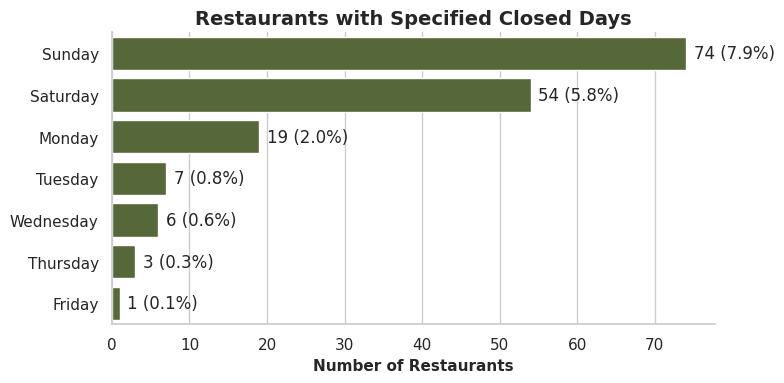

In [16]:
# Closed days distribution

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=closed_days_summary["restaurants"],
    y=closed_days_summary.index,
    color=colors[0]
)

for i, row in enumerate(closed_days_summary.itertuples()):
    ax.text(
        row.restaurants + 1,
        i,
        f"{row.restaurants} ({row.share_of_all_restaurants_pct:.1f}%)",
        va="center"
    )

plt.title("Restaurants with Specified Closed Days", fontsize=14, fontweight="bold")
plt.xlabel("Number of Restaurants", fontsize=11, fontweight="bold")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

In [17]:
# Parse daily opening duration

def parse_opening_hours(hours):
    if pd.isna(hours):
        return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan])

    hours = str(hours).strip()

    if hours == "Closed":
        return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan])

    if hours == "00:00 - 23:59":
        return pd.Series(["00:00", "23:59", 0.0, 24.0, 24.0])

    match = re.search(r"(.+?)\s*[-–]\s*(.+)", hours)
    if not match:
        return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan])

    start_str, end_str = match.groups()
    start_str = start_str.strip()
    end_str = end_str.strip()

    if "AM" not in start_str and "PM" not in start_str:
        period = "PM" if "PM" in end_str else "AM"
        start_str = f"{start_str} {period}"

    try:
        start = datetime.strptime(start_str, "%I:%M %p")
        end = datetime.strptime(end_str, "%I:%M %p")
    except ValueError:
        return pd.Series([np.nan, np.nan, np.nan, np.nan, np.nan])

    opening_time = start.strftime("%H:%M")
    closing_time = end.strftime("%H:%M")
    opening_hour = start.hour + start.minute / 60
    closing_hour = end.hour + end.minute / 60

    if closing_hour <= opening_hour:
        closing_hour += 24

    duration = closing_hour - opening_hour

    return pd.Series([opening_time, closing_time, opening_hour, closing_hour, duration])


df[["opening_time", "closing_time", "opening_hour", "closing_hour", "opening_duration_hours"]] = (
    df["standard_opening_hours"].apply(parse_opening_hours)
)

df[["standard_opening_hours", "opening_time", "closing_time",
    "opening_hour", "closing_hour", "opening_duration_hours"]].dropna().head()

,standard_opening_hours,opening_time,closing_time,opening_hour,closing_hour,opening_duration_hours
0,8:00 AM – 6:00 PM,08:00,18:00,8.0,18.0,10.0
1,11:00 AM – 9:00 PM,11:00,21:00,11.0,21.0,10.0
2,00:00 - 23:59,00:00,23:59,0.0,24.0,24.0
3,9:00 AM – 10:00 PM,09:00,22:00,9.0,22.0,13.0
4,2:00 – 11:00 PM,14:00,23:00,14.0,23.0,9.0


In [18]:
# Opening duration parsing summary

duration_summary = pd.DataFrame({
    "restaurants": [
        df["standard_opening_hours"].notna().sum(),
        df["opening_duration_hours"].notna().sum(),
        df["standard_opening_hours"].eq("Closed").sum(),
        df["standard_opening_hours"].notna().sum() - df["opening_duration_hours"].notna().sum()
    ],
    "share_pct": [
        df["standard_opening_hours"].notna().mean() * 100,
        df["opening_duration_hours"].notna().mean() * 100,
        df["standard_opening_hours"].eq("Closed").mean() * 100,
        (
            df["standard_opening_hours"].notna().sum()
            - df["opening_duration_hours"].notna().sum()
        ) / len(df) * 100
    ]
}, index=[
    "Opening hours available",
    "Opening duration parsed",
    "Marked as closed",
    "Opening duration unparsed"
]).round(2)

duration_summary

,restaurants,share_pct
Opening hours available,848,90.79
Opening duration parsed,845,90.47
Marked as closed,2,0.21
Opening duration unparsed,3,0.32


In [19]:
# Opening duration summary

opening_duration_summary = (
    df["opening_duration_hours"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9])
    .round(2)
    .to_frame("opening_duration_hours")
)

opening_duration_summary

,opening_duration_hours
count,845.00
mean,12.09
std,3.11
min,3.00
25%,11.00
50%,12.00
75%,12.50
90%,14.00
max,24.00


In [20]:
# Opening duration groups

df["opening_duration_group"] = pd.cut(
    df["opening_duration_hours"],
    bins=[0, 8, 10, 12, 16, 24],
    labels=["Up to 8h", "8-10h", "10-12h", "12-16h", "16-24h"],
    include_lowest=True
)

duration_groups = df["opening_duration_group"].value_counts().sort_index().to_frame("restaurants")

duration_groups["share_pct"] = (
    duration_groups["restaurants"] / df["opening_duration_hours"].notna().sum() * 100
).round(2)

duration_groups

,restaurants,share_pct
opening_duration_group,,
Up to 8h,36,4.26
8-10h,136,16.09
10-12h,446,52.78
12-16h,178,21.07
16-24h,49,5.80


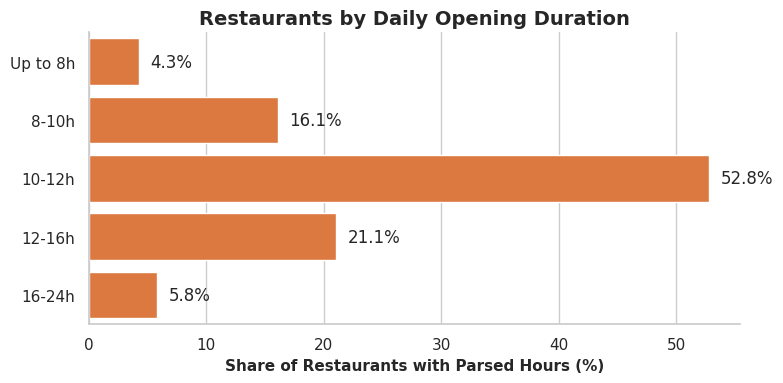

In [21]:
# Restaurants by daily opening duration

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=duration_groups["share_pct"],
    y=duration_groups.index,
    color=colors[1]
)

for i, v in enumerate(duration_groups["share_pct"]):
    ax.text(v + 1, i, f"{v:.1f}%", va="center")

plt.title("Restaurants by Daily Opening Duration", fontsize=14, fontweight="bold")
plt.xlabel("Share of Restaurants with Parsed Hours (%)", fontsize=11, fontweight="bold")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

In [22]:
# Opening and closing hour summary

opening_closing_summary = pd.DataFrame({
    "opening_hour": df["opening_hour"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]),
    "closing_hour": df["closing_hour"].describe(percentiles=[0.25, 0.5, 0.75, 0.9])
}).round(2)

opening_closing_summary

,opening_hour,closing_hour
count,845.00,845.00
mean,9.48,21.57
std,2.55,1.58
min,0.00,11.00
25%,9.00,21.00
50%,10.00,22.00
75%,11.00,22.50
90%,12.00,23.00
max,20.00,29.00


In [23]:
# Opening hour groups

df["opening_hour_group"] = pd.cut(
    df["opening_hour"],
    bins=[0, 7, 9, 11, 13, 24],
    labels=["Before 7:00", "7:00-9:00", "9:00-11:00", "11:00-13:00", "After 13:00"],
    include_lowest=True
)

opening_hour_groups = df["opening_hour_group"].value_counts().sort_index().to_frame("restaurants")

opening_hour_groups["share_pct"] = (
    opening_hour_groups["restaurants"] / df["opening_hour"].notna().sum() * 100
).round(2)

opening_hour_groups

,restaurants,share_pct
opening_hour_group,,
Before 7:00,57,6.75
7:00-9:00,250,29.59
9:00-11:00,430,50.89
11:00-13:00,95,11.24
After 13:00,13,1.54


In [24]:
# Closing hour groups

df["closing_hour_group"] = pd.cut(
    df["closing_hour"],
    bins=[0, 18, 20, 22, 30],
    labels=["Before 18:00", "18:00-20:00", "20:00-22:00", "After 22:00"],
    include_lowest=True
)

closing_hour_groups = df["closing_hour_group"].value_counts().sort_index().to_frame("restaurants")

closing_hour_groups["share_pct"] = (
    closing_hour_groups["restaurants"] / df["closing_hour"].notna().sum() * 100
).round(2)

closing_hour_groups

,restaurants,share_pct
closing_hour_group,,
Before 18:00,48,5.68
18:00-20:00,107,12.66
20:00-22:00,473,55.98
After 22:00,217,25.68


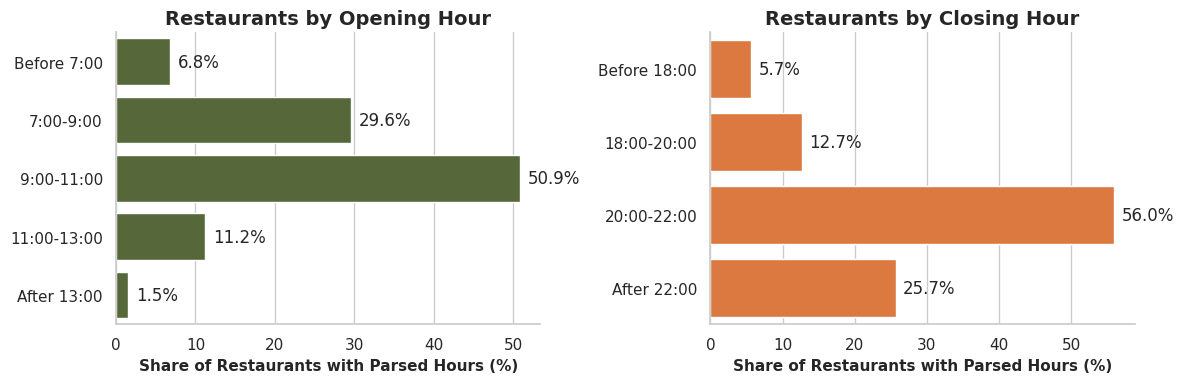

In [25]:
# Opening and closing hour distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x=opening_hour_groups["share_pct"],
    y=opening_hour_groups.index,
    color=colors[0],
    ax=axes[0]
)

sns.barplot(
    x=closing_hour_groups["share_pct"],
    y=closing_hour_groups.index,
    color=colors[1],
    ax=axes[1]
)

for i, v in enumerate(opening_hour_groups["share_pct"]):
    axes[0].text(v + 1, i, f"{v:.1f}%", va="center")

for i, v in enumerate(closing_hour_groups["share_pct"]):
    axes[1].text(v + 1, i, f"{v:.1f}%", va="center")

axes[0].set_title("Restaurants by Opening Hour", fontsize=14, fontweight="bold")
axes[1].set_title("Restaurants by Closing Hour", fontsize=14, fontweight="bold")

axes[0].set_xlabel("Share of Restaurants with Parsed Hours (%)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Share of Restaurants with Parsed Hours (%)", fontsize=11, fontweight="bold")

for ax in axes:
    ax.set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

**Operating Hours and Weekly Availability Findings**

Operating hours provide an important operational layer for understanding restaurant accessibility in the Lviv market.

Standard opening hours are available for **848 restaurants (90.8%)**, and daily opening duration was successfully parsed for **845 restaurants (90.5%)**. This means that operating hours are sufficiently complete for market-level comparison.

The typical restaurant in Lviv operates for around **12 hours per day**. The average daily opening duration is **12.1 hours**, while the median is **12.0 hours**. Most restaurants fall within a relatively narrow operating range: the 25th percentile is **11.0 hours**, the 75th percentile is **12.5 hours**, and 90% of restaurants operate up to **14.0 hours** per day.

The most common operating duration is **10-12 hours**, covering **446 restaurants (52.8%)** with parsed opening hours. Another **21.1%** operate for **12–16 hours**, while only **4.3%** operate up to **8 hours** per day. This suggests that short daily schedules are relatively uncommon in the Lviv restaurant market.

Opening and closing patterns are also relatively concentrated. Most restaurants open between **9:00 and 11:00**, which accounts for **50.9%** of restaurants with parsed hours. Another **29.6%** open between **7:00 and 9:00**. The median opening time is **10:00**.

Closing times are concentrated in the evening. **56.0%** of restaurants close between **20:00 and 22:00**, while **25.7%** close after **22:00**. The median closing time is **22:00**, and 90% of restaurants close by **23:00**.

Only **37 restaurants (4.0%)** appear to operate 24/7, which means that round-the-clock availability is rare and likely limited to specific formats or high-demand locations.

Weekly closure is also relatively uncommon in the structured data. Only **93 restaurants (10.0%)** specify regular closed days. **Sunday** is the most common closure day, with **74 restaurants (7.9%)** explicitly marked as closed on Sunday, followed by **Saturday (54 restaurants, 5.8%)** and **Monday (19 restaurants, 2.0%)**.

Overall, the Lviv restaurant market shows broad daily and weekly availability. A restaurant that operates with shorter daily hours, closes earlier than the market norm, or is closed on Sunday may therefore face an accessibility disadvantage compared with the broader market, especially during evening and weekend demand periods.

### **4.4. District Distribution**

In [26]:
# Restaurant distribution by district

district_summary = df["district"].value_counts().to_frame("restaurants")

district_summary["share_pct"] = (
    district_summary["restaurants"] / len(df) * 100
).round(2)

district_summary

,restaurants,share_pct
district,,
Frankivskyi,208,22.27
Sykhivskyi,182,19.49
Shevchenkivskyi,153,16.38
Zaliznychnyi,149,15.95
Halytskyi,138,14.78
Lychakivskyi,104,11.13


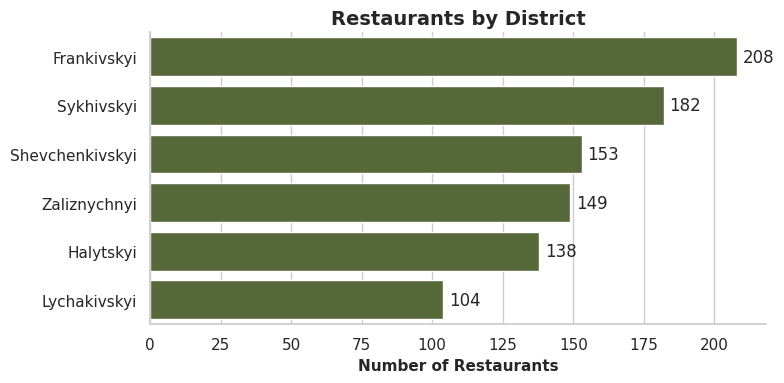

In [27]:
# Restaurant distribution by district

districts = df["district"].value_counts()

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    x=districts.values,
    y=districts.index,
    color=colors[0]
)

for i, v in enumerate(districts.values):
    ax.text(v + 2, i, v, va="center")

plt.title("Restaurants by District", fontsize=14, fontweight="bold")
plt.xlabel("Number of Restaurants", fontsize=11, fontweight="bold")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

**District Distribution Findings**

Restaurant supply is distributed across all six districts of Lviv, with no single district fully dominating the market.

**Frankivskyi** is the largest restaurant cluster, with **208 restaurants**, accounting for **22.3%** of all establishments in the dataset. It is followed by **Sykhivskyi (182 restaurants, 19.5%)** and **Shevchenkivskyi (153 restaurants, 16.4%)**.

Together, these three districts represent more than half of the total restaurant supply, indicating that a large share of the market is concentrated in major residential and commercial areas rather than only in the historical city center.

**Halytskyi**, despite being the central and tourist-oriented district, accounts for **138 restaurants (14.8%)**. This suggests that the restaurant market in Lviv is not limited to the city center and that local neighborhood demand plays an important role.

Overall, the district distribution shows a relatively balanced restaurant market, where competition exists across the city but is strongest in Frankivskyi, Sykhivskyi, and Shevchenkivskyi districts.

## **5. Cuisine Landscape**

In [28]:
# Split cuisine tags

cuisine_exploded = (
    df.assign(
        cuisine_type=df["cuisine_type"].str.split(" | ", regex=False)
    )
    .explode("cuisine_type")
)

In [29]:
# Cuisine summary

cuisine_summary = cuisine_exploded["cuisine_type"].value_counts().to_frame("restaurants")

cuisine_summary["share_pct"] = (
    cuisine_summary["restaurants"]
    / df["place_id"].nunique()
    * 100
).round(2)

cuisine_summary

,restaurants,share_pct
cuisine_type,,
Restaurant (unclassified),271,29.01
Desserts & Coffee,171,18.31
Pizza,127,13.60
Kebab,106,11.35
Bakery,86,9.21
Sushi,48,5.14
Fast Food,44,4.71
Grill,33,3.53
Bistro,29,3.10


In [30]:
# Unclassified restaurants

unclassified = df[df["cuisine_type"] == "Restaurant (unclassified)"]

print(f"Unclassified restaurants: {len(unclassified)}")
print(f"Share of dataset: {len(unclassified) / len(df) * 100:.1f}%")

Unclassified restaurants: 271
Share of dataset: 29.0%


In [31]:
# Unclassified restaurants by business model

unclassified_model = unclassified["business_model"].value_counts().to_frame("restaurants")

unclassified_model["share_pct"] = (
    unclassified_model["restaurants"] / len(unclassified) * 100
).round(2)

unclassified_model

,restaurants,share_pct
business_model,,
Restaurant with Delivery,125,46.13
Dine-in Restaurant,75,27.68
Restaurant,29,10.70
Takeaway Spot,18,6.64
Delivery Only / Dark Kitchen,17,6.27
Hotel Restaurant,7,2.58


In [32]:
# Unclassified restaurants by district

unclassified_district = unclassified["district"].value_counts().to_frame("restaurants")

unclassified_district["share_pct"] = (
    unclassified_district["restaurants"] / len(unclassified) * 100
).round(2)

unclassified_district

,restaurants,share_pct
district,,
Frankivskyi,66,24.35
Halytskyi,58,21.40
Sykhivskyi,48,17.71
Shevchenkivskyi,39,14.39
Zaliznychnyi,33,12.18
Lychakivskyi,27,9.96


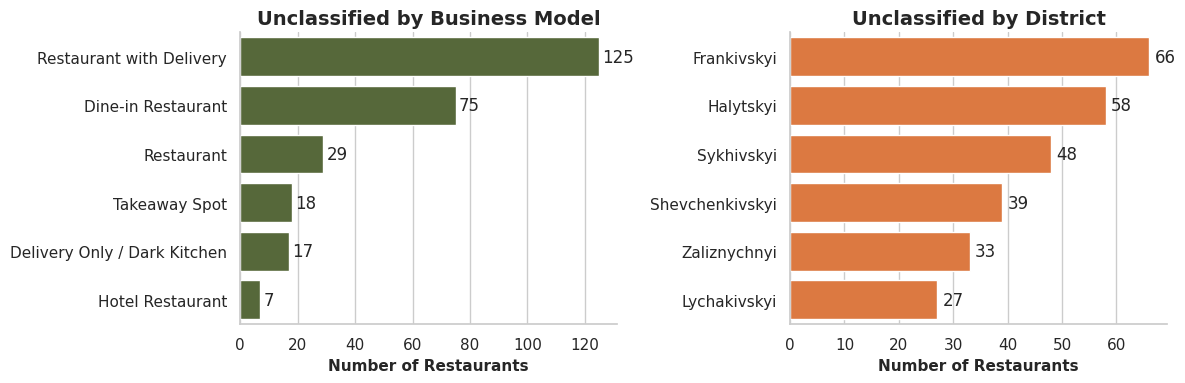

In [33]:
# Unclassified restaurants overview

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    x=unclassified_model["restaurants"],
    y=unclassified_model.index,
    color=colors[0],
    ax=axes[0]
)

sns.barplot(
    x=unclassified_district["restaurants"],
    y=unclassified_district.index,
    color=colors[1],
    ax=axes[1]
)

for ax in axes:
    for i, v in enumerate(ax.containers[0].datavalues):
        ax.text(v + 1, i, int(v), va="center")

    ax.set_xlabel("Number of Restaurants", fontsize=11, fontweight="bold")
    ax.set_ylabel("")

axes[0].set_title("Unclassified by Business Model", fontsize=14, fontweight="bold")
axes[1].set_title("Unclassified by District", fontsize=14, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

**Cuisine Classification Approach**

During dataset preparation, some restaurants could not be reliably assigned to a specific cuisine category and were labeled as **Restaurant (unclassified)**.

This category does not represent an actual cuisine type. Instead, it reflects restaurants where cuisine identification was not reliable enough based on available Google Maps data, restaurant names, keywords, and classification rules.

A separate check was performed before excluding this category from cuisine-specific analysis. **Restaurant (unclassified)** includes **271 restaurants**, which represents **29.0%** of the full dataset. Because this is a substantial share, it was reviewed separately by business model and district.

Most unclassified restaurants are general restaurant formats rather than niche or unusual concepts. The largest share belongs to **Restaurant with Delivery** with **125 restaurants (46.1%)**, followed by **Dine-in Restaurant** with **75 restaurants (27.7%)** and general **Restaurant** with **29 restaurants (10.7%)**.

By district, unclassified restaurants are most concentrated in **Frankivskyi (66 restaurants)** and **Halytskyi (58 restaurants)**. The strong presence in Halytskyi is notable because this district includes many central and tourist-oriented venues that may position themselves around atmosphere, location, or general dining experience rather than a clearly defined cuisine.

This confirms that **Restaurant (unclassified)** should not be interpreted as a cuisine segment. It is treated as a classification limitation rather than a market category.

For this reason, unclassified restaurants are excluded from cuisine-specific charts, rankings, and market share calculations. However, they remain part of the broader market analysis, including district distribution, business model structure, service availability, ratings, and overall market size.

In [34]:
# Exclude unclassified restaurants

cuisine_market = cuisine_summary.drop("Restaurant (unclassified)")

### **5.1. Cuisine Pareto Analysis**

In [35]:
# Cuisine Pareto analysis

cuisine_market["cumulative_share_pct"] = (
    cuisine_market["share_pct"]
    .cumsum()
    .round(2)
)

cuisine_market.head(15)

,restaurants,share_pct,cumulative_share_pct
cuisine_type,,,
Desserts & Coffee,171,18.31,18.31
Pizza,127,13.60,31.91
Kebab,106,11.35,43.26
Bakery,86,9.21,52.47
Sushi,48,5.14,57.61
Fast Food,44,4.71,62.32
Grill,33,3.53,65.85
Bistro,29,3.10,68.95
Georgian,29,3.10,72.05


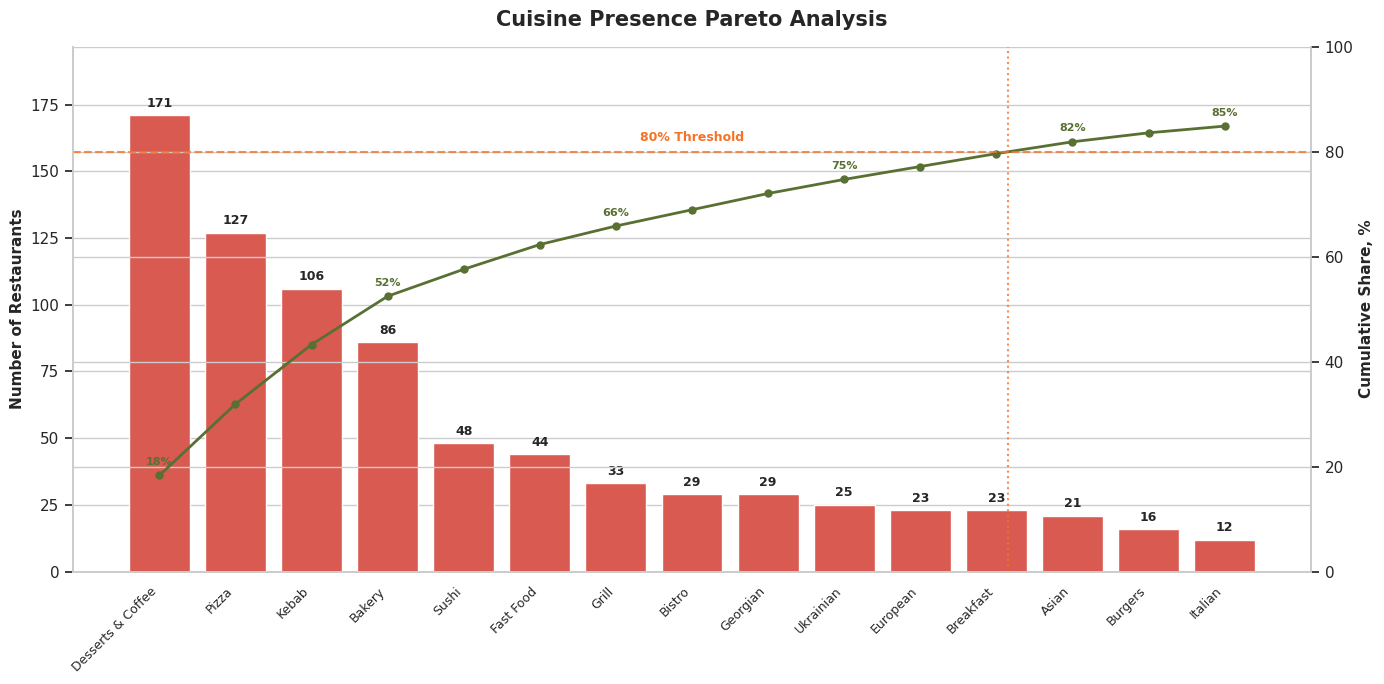

In [36]:
# Cuisine Pareto chart

cuisine_pareto = cuisine_market.head(15).copy()
threshold_idx = np.where(cuisine_pareto["cumulative_share_pct"] >= 80)[0][0]

x_prev, x_next = threshold_idx - 1, threshold_idx
y_prev = cuisine_pareto["cumulative_share_pct"].iloc[x_prev]
y_next = cuisine_pareto["cumulative_share_pct"].iloc[x_next]
threshold_x = x_prev + (80 - y_prev) / (y_next - y_prev)

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(
    x=cuisine_pareto.index,
    y=cuisine_pareto["restaurants"],
    color=colors[4],
    ax=ax1
)

for i, v in enumerate(cuisine_pareto["restaurants"]):
    ax1.text(i, v + 2, v, ha="center", va="bottom", fontsize=9, fontweight="bold")

ax1.set_title("Cuisine Presence Pareto Analysis", fontsize=15, fontweight="bold", pad=15)
ax1.set_xlabel("")
ax1.set_ylabel("Number of Restaurants", fontsize=11, fontweight="bold")
ax1.set_ylim(0, cuisine_pareto["restaurants"].max() * 1.15)
ax1.set_xticks(range(len(cuisine_pareto)))
ax1.set_xticklabels(cuisine_pareto.index, rotation=45, ha="right", fontsize=9)

ax2 = ax1.twinx()

ax2.plot(
    range(len(cuisine_pareto)),
    cuisine_pareto["cumulative_share_pct"],
    marker="o",
    markersize=5,
    linewidth=2,
    color=colors[0]
)

for i, v in enumerate(cuisine_pareto["cumulative_share_pct"]):
    if i in [0, 3, 6, 9, 12, 14]:
        ax2.text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=8, color=colors[0], fontweight="bold")

ax2.axhline(y=80, color=colors[1], linestyle="--", linewidth=1.5, alpha=0.8)
ax2.axvline(x=threshold_x, color=colors[1], linestyle=":", linewidth=1.5, alpha=0.8)
ax2.text(
    (len(cuisine_pareto) - 1) / 2,
    82,
    "80% Threshold",
    color=colors[1],
    ha="center",
    fontsize=9,
    fontweight="bold"
)

ax2.set_ylabel("Cumulative Share, %", fontsize=11, fontweight="bold")
ax2.set_ylim(0, 100)
ax2.set_yticks(range(0, 101, 20))

sns.despine(right=False)
plt.tight_layout()
plt.show()

**Cuisine Pareto Findings**

The Lviv restaurant market shows a moderately concentrated cuisine structure.

**Desserts & Coffee** is the largest identified cuisine segment, with **171 restaurants**, followed by **Pizza (127)**, **Kebab (106)**, and **Bakery (86)**. Together, these four categories account for **52.5%** of restaurant presence.

The Pareto curve shows that the first **12 cuisine categories** already cover almost **80%** of the market, reaching **79.7%** after **Breakfast**. The threshold is crossed by the next category, **Asian**, which brings cumulative cuisine presence to **81.9%**.

This means that although the market includes a wide variety of cuisines, most restaurant supply is concentrated around a limited set of popular and scalable categories.

At the same time, the remaining categories form a long tail of smaller cuisine segments, which adds diversity to the Lviv food market but represents a much smaller share of total restaurant presence.

### **5.2. Cuisine Distribution by District**

In [37]:
# Cuisine distribution by district

top_cuisines = cuisine_market.head(10).index

cuisine_district_pivot = (
    pd.crosstab(cuisine_exploded["cuisine_type"], cuisine_exploded["district"])
    .loc[top_cuisines, district_summary.index]
)

cuisine_district_pivot

district,Frankivskyi,Sykhivskyi,Shevchenkivskyi,Zaliznychnyi,Halytskyi,Lychakivskyi
cuisine_type,,,,,,
Desserts & Coffee,40,29,27,26,27,22
Pizza,25,30,26,28,6,12
Kebab,27,21,16,23,6,13
Bakery,14,21,15,12,15,9
Sushi,13,15,9,4,2,5
Fast Food,11,8,7,10,3,5
Grill,8,4,3,2,8,8
Bistro,4,6,7,10,0,2
Georgian,3,9,6,3,6,2


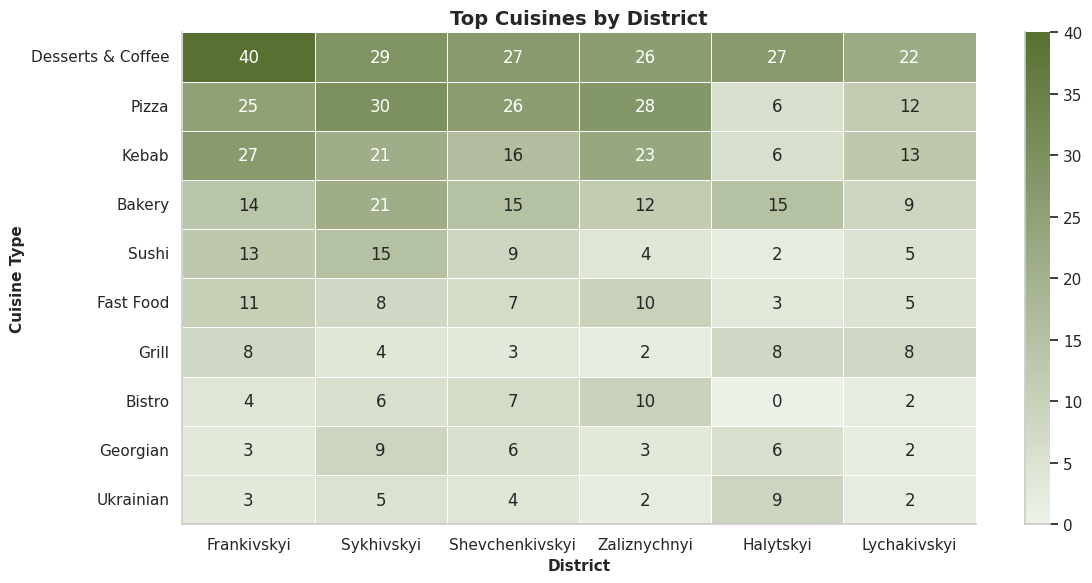

In [38]:
# Cuisine distribution by district heatmap

plt.figure(figsize=(12, 6))

ax = sns.heatmap(
    cuisine_district_pivot,
    annot=True,
    fmt=".0f",
    cmap=sns.light_palette(colors[0], as_cmap=True),
    linewidths=0.5
)

plt.title("Top Cuisines by District", fontsize=14, fontweight="bold")
plt.xlabel("District", fontsize=11, fontweight="bold")
plt.ylabel("Cuisine Type", fontsize=11, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

**Cuisine Distribution by District Findings**

Cuisine distribution varies noticeably across Lviv districts, although several categories are broadly represented across the city.

**Desserts & Coffee** is the most evenly distributed major cuisine category. It leads in every district, with the highest concentration in **Frankivskyi (40 restaurants)** and strong presence in **Sykhivskyi, Shevchenkivskyi, Zaliznychnyi, Halytskyi, and Lychakivskyi**. This confirms that coffee and dessert-oriented concepts are a city-wide market segment rather than a district-specific niche.

**Pizza** and **Kebab** are especially strong in large residential and commercial districts. Pizza has the highest presence in **Sykhivskyi (30)** and **Zaliznychnyi (28)**, while Kebab is strongest in **Frankivskyi (27)** and **Zaliznychnyi (23)**. These categories appear to be closely linked to high-frequency, convenient food consumption.

**Halytskyi District** shows a different structure compared with other districts. It has relatively low representation of Pizza and Kebab, but a stronger presence of **Ukrainian cuisine (9)** and **Grill (8)**. This may reflect the district's role as the historical and tourist center, where more traditional and experience-oriented restaurant formats are more visible.

**Frankivskyi** appears to be the most diversified cuisine cluster, leading in Desserts & Coffee, Kebab, Fast Food, and Grill. This supports its earlier position as the largest restaurant district in the dataset.

Overall, the heatmap shows that while several cuisine categories are present across the entire city, individual districts still differ in cuisine mix, suggesting that restaurant competition and customer demand patterns vary by location.

### **5.3. Cuisine Reputation Analysis**

This section compares cuisine categories by customer reputation.

To reduce noise from very small cuisine segments, only cuisines with at least **10 restaurants** are included in the analysis. The main comparison metric is **Bayesian Rating**, because it accounts for both rating level and review volume.

In [39]:
# Cuisine reputation summary

cuisine_reputation = (
    cuisine_exploded[cuisine_exploded["cuisine_type"].isin(cuisine_market.index)]
    .groupby("cuisine_type")
    .agg(
        restaurants=("place_id", "nunique"),
        rated_restaurants=("has_rating", "sum"),
        avg_rating=("rating", "mean"),
        avg_bayesian_rating=("bayesian_rating", "mean"),
        avg_reviews=("reviews_count", "mean"),
        median_reviews=("reviews_count", "median")
    )
    .round(2)
)

cuisine_reputation["rated_share_pct"] = (
    cuisine_reputation["rated_restaurants"] / cuisine_reputation["restaurants"] * 100
).round(1)

cuisine_reputation = (
    cuisine_reputation[cuisine_reputation["restaurants"] >= 10]
    .sort_values("avg_bayesian_rating", ascending=False)
)

cuisine_reputation

,restaurants,rated_restaurants,avg_rating,avg_bayesian_rating,avg_reviews,median_reviews,rated_share_pct
cuisine_type,,,,,,,
Grill,33,29,4.47,4.40,957.27,230.0,87.9
Asian,21,18,4.13,4.39,445.14,59.0,85.7
Georgian,29,26,4.23,4.38,571.00,228.0,89.7
Desserts & Coffee,171,167,4.41,4.37,674.26,220.0,97.7
Italian,12,12,4.53,4.37,1427.00,672.5,100.0
Pizza,127,120,4.37,4.36,306.86,133.0,94.5
Bakery,86,84,4.35,4.36,515.53,199.5,97.7
Ukrainian,25,22,4.14,4.36,1755.08,211.0,88.0
Fast Food,44,38,4.29,4.34,1158.70,91.0,86.4


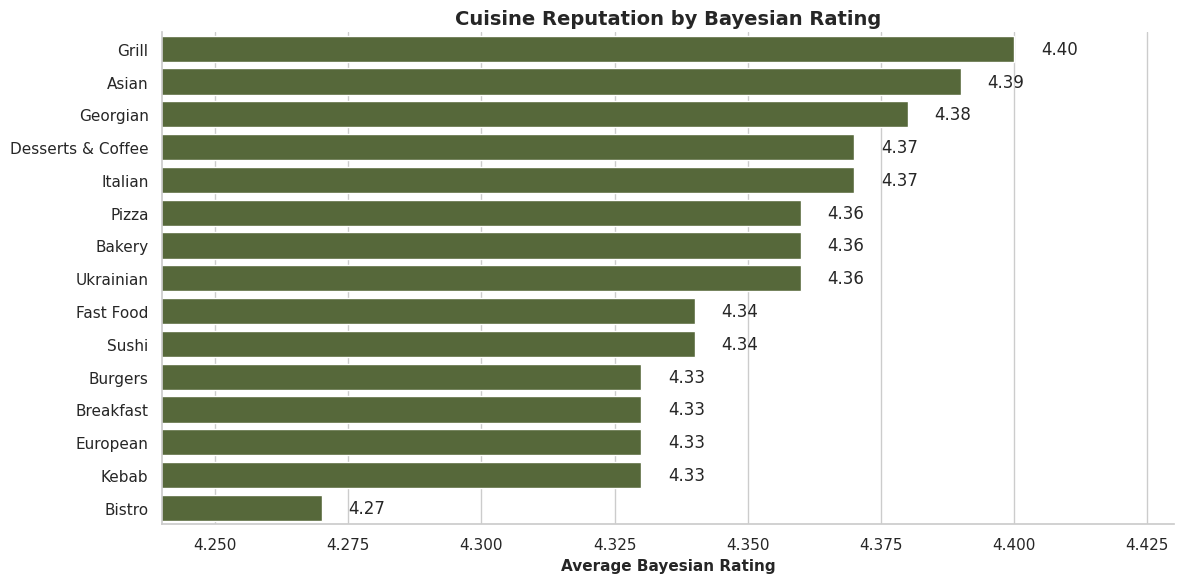

In [40]:
# Cuisine reputation by Bayesian Rating

cuisine_reputation_plot = cuisine_reputation.sort_values("avg_bayesian_rating", ascending=False)

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=cuisine_reputation_plot["avg_bayesian_rating"],
    y=cuisine_reputation_plot.index,
    color=colors[0]
)

for i, v in enumerate(cuisine_reputation_plot["avg_bayesian_rating"]):
    ax.text(v + 0.005, i, f"{v:.2f}", va="center")

plt.title("Cuisine Reputation by Bayesian Rating", fontsize=14, fontweight="bold")
plt.xlabel("Average Bayesian Rating", fontsize=11, fontweight="bold")
plt.ylabel("")

plt.xlim(
    cuisine_reputation_plot["avg_bayesian_rating"].min() - 0.03,
    cuisine_reputation_plot["avg_bayesian_rating"].max() + 0.03
)

sns.despine()
plt.tight_layout()
plt.show()

**Cuisine Reputation Findings**

Cuisine reputation is relatively strong across all major cuisine categories, with average Bayesian Ratings ranging from **4.27** to **4.40**.

**Grill**, **Asian**, and **Georgian** show the highest average Bayesian Ratings among cuisines with at least 10 restaurants. However, the differences between categories are moderate, suggesting that no single cuisine segment strongly outperforms the rest of the market by reputation.

Large and mainstream categories such as **Desserts & Coffee**, **Pizza**, and **Bakery** also maintain strong Bayesian Ratings, which indicates that high-volume cuisine segments are not necessarily associated with lower customer satisfaction.

**Bistro** has the lowest average Bayesian Rating among the analyzed cuisines, but its score remains relatively high at **4.27**. This suggests that even lower-ranked cuisine categories still maintain generally positive customer feedback.

Overall, cuisine reputation in Lviv appears consistently strong, while differences between cuisine categories are more subtle than the differences in market size or district distribution. The relationship between reputation and market saturation is explored further in the Competitive Positioning section below.

## **6. Restaurant Reputation & Customer Engagement**

### **6.1. Rating Coverage and Distribution**

In [41]:
# Rating coverage summary

rating_coverage = pd.DataFrame({
    "restaurants": df["has_rating"].value_counts()
})

rating_coverage["share_pct"] = (
    rating_coverage["restaurants"] / len(df) * 100
).round(2)

rating_coverage

,restaurants,share_pct
has_rating,,
True,861,92.18
False,73,7.82


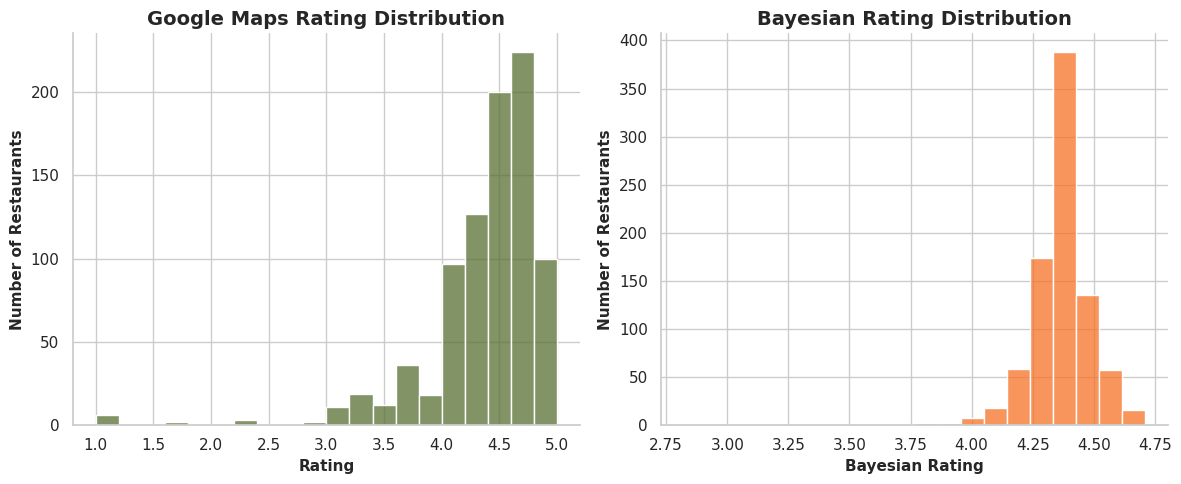

In [42]:
# Rating distributions

rated = df[df["has_rating"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=rated, x="rating", bins=20, color=colors[0], ax=axes[0])
sns.histplot(data=rated, x="bayesian_rating", bins=20, color=colors[1], ax=axes[1])

axes[0].set_title("Google Maps Rating Distribution", fontsize=14, fontweight="bold")
axes[1].set_title("Bayesian Rating Distribution", fontsize=14, fontweight="bold")

axes[0].set_xlabel("Rating", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Bayesian Rating", fontsize=11, fontweight="bold")

for ax in axes:
    ax.set_ylabel("Number of Restaurants", fontsize=11, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

**Rating Coverage and Distribution Findings**

The dataset has strong rating coverage: **861 restaurants (92.2%)** have Google Maps rating data, while only **73 restaurants (7.8%)** remain unrated.

Google Maps ratings are heavily concentrated in the upper range, with most restaurants rated between **4.0 and 5.0**. This suggests that customer feedback in the Lviv restaurant market is generally positive, but it also means that raw ratings alone may not be sufficient for meaningful comparison.

The Bayesian Rating distribution is much narrower and more centered, mostly ranging between approximately **4.2 and 4.5**. This adjustment reduces the impact of extreme ratings and small review counts, making it more reliable for comparing restaurant reputation across the market.

Overall, the market shows consistently strong customer ratings, but Bayesian Rating provides a more stable metric for further competitive analysis.

### **6.2. Review Volume Distribution**

In [43]:
# Review volume summary

review_summary = (
    rated["reviews_count"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    .round(0)
    .to_frame("reviews_count")
)

review_summary

,reviews_count
count,861.0
mean,601.0
std,1773.0
min,1.0
25%,37.0
50%,163.0
75%,520.0
90%,1404.0
95%,2207.0
99%,7651.0


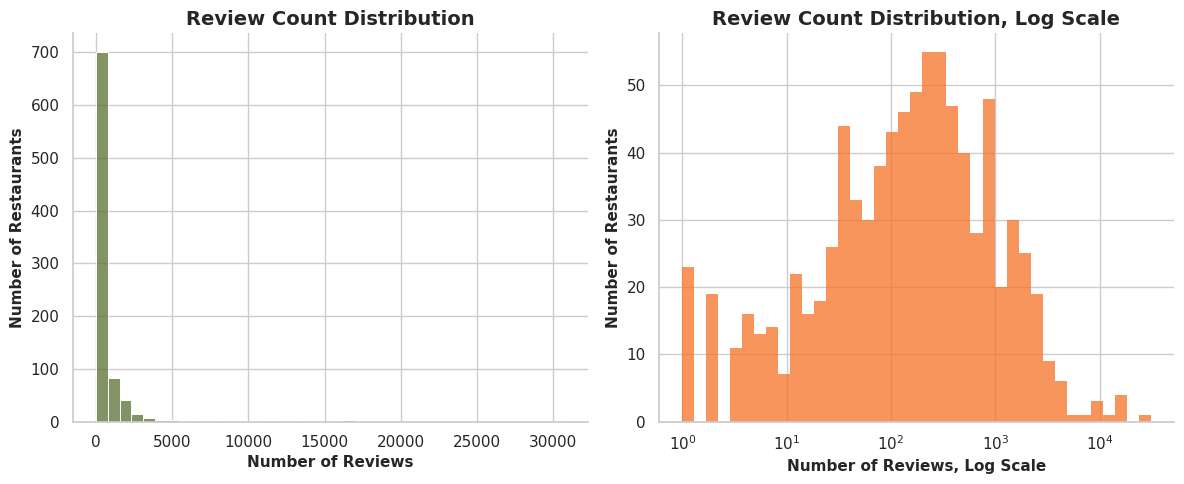

In [44]:
# Review volume distribution

review_bins = np.logspace(
    np.log10(rated["reviews_count"].min()),
    np.log10(rated["reviews_count"].max()),
    40
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=rated, x="reviews_count", bins=40, color=colors[0], ax=axes[0])
sns.histplot(data=rated, x="reviews_count", bins=review_bins, color=colors[1], ax=axes[1])

axes[1].set_xscale("log")

axes[0].set_title("Review Count Distribution", fontsize=14, fontweight="bold")
axes[1].set_title("Review Count Distribution, Log Scale", fontsize=14, fontweight="bold")

axes[0].set_xlabel("Number of Reviews", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Number of Reviews, Log Scale", fontsize=11, fontweight="bold")

for ax in axes:
    ax.set_ylabel("Number of Restaurants", fontsize=11, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

**Review Volume Findings**

Review volume is highly uneven across restaurants.

The median restaurant has **163 reviews**, while the average is much higher at **601 reviews**, indicating a strong right-skewed distribution. This means that a relatively small number of highly visible restaurants accumulate a disproportionately large share of customer reviews.

Most restaurants remain within a moderate review range: **75%** have fewer than **520 reviews**, and **90%** have fewer than **1,404 reviews**. At the same time, the maximum review count reaches **30,735**, showing the presence of several exceptionally popular or long-established restaurants.

The standard review count distribution is strongly compressed by these high-review outliers. The log-scale distribution provides a clearer view of the main market, where most restaurants are concentrated between tens and hundreds of reviews.

Because review volume varies so strongly, raw rating alone is not sufficient for competitive comparison. Restaurants with similar ratings may differ significantly in customer engagement, visibility, and market maturity.

### **6.3. Rating Reliability Analysis**

In [45]:
# Rating reliability correlations

rating_reliability_corr = rated[
    ["rating", "bayesian_rating", "reviews_count"]
].corr().round(2)

rating_reliability_corr

,rating,bayesian_rating,reviews_count
rating,1.00,0.52,0.06
bayesian_rating,0.52,1.00,0.17
reviews_count,0.06,0.17,1.00


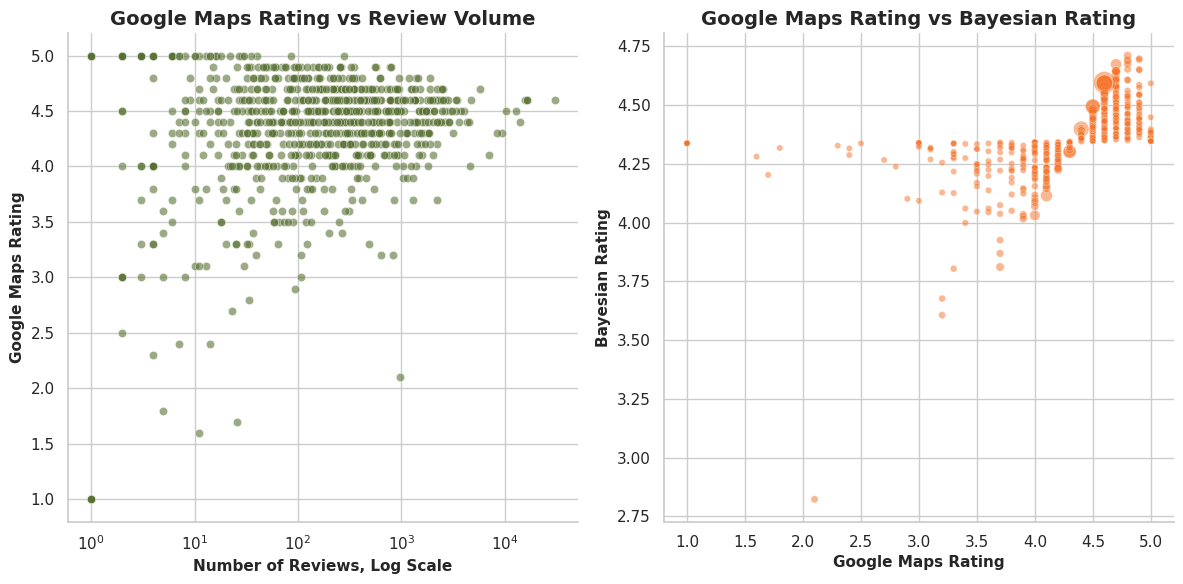

In [46]:
# Rating reliability analysis

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(
    data=rated,
    x="reviews_count",
    y="rating",
    alpha=0.6,
    color=colors[0],
    ax=axes[0]
)

sns.scatterplot(
    data=rated,
    x="rating",
    y="bayesian_rating",
    size="reviews_count",
    sizes=(20, 250),
    alpha=0.5,
    color=colors[1],
    legend=False,
    ax=axes[1]
)

axes[0].set_xscale("log")

axes[0].set_title("Google Maps Rating vs Review Volume", fontsize=14, fontweight="bold")
axes[1].set_title("Google Maps Rating vs Bayesian Rating", fontsize=14, fontweight="bold")

axes[0].set_xlabel("Number of Reviews, Log Scale", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Google Maps Rating", fontsize=11, fontweight="bold")

axes[0].set_ylabel("Google Maps Rating", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Bayesian Rating", fontsize=11, fontweight="bold")

sns.despine()
plt.tight_layout()
plt.show()

**Rating Reliability Findings**

Raw Google Maps rating shows almost no correlation with review volume. The correlation between rating and reviews_count is only **0.06**, which means that restaurants with many reviews do not necessarily have higher ratings than restaurants with fewer reviews.

The first scatter plot confirms this visually: restaurants with low and high review counts can both have ratings close to **4.5-5.0**, while some restaurants with relatively few reviews show extreme rating values. This makes raw rating less reliable for direct competitive comparison.

The correlation between rating and bayesian_rating is moderate at **0.52**, showing that Bayesian Rating still reflects customer rating quality but adjusts it based on review volume.

The correlation between bayesian_rating and reviews_count is **0.17**, which should be interpreted carefully because review volume is already part of the Bayesian Rating calculation. This relationship is expected by design rather than a fully independent market pattern.

Overall, this analysis confirms why Bayesian Rating is more appropriate for restaurant ranking and competitive positioning. It reduces the impact of extreme ratings based on small review counts and provides a more stable reputation metric for comparing restaurants across the market.

### **6.4. Top and Bottom Restaurants by Bayesian Rating**

In [47]:
# Top restaurants by Bayesian Rating

top_restaurants_all = (
    df[df["has_rating"]]
    .sort_values("bayesian_rating", ascending=False)
    [["found_name", "district", "cuisine_type", "business_model", "rating", "bayesian_rating", "reviews_count"]]
    .head(20)
    .copy()
)

top_restaurants_all["restaurant_label"] = (
    top_restaurants_all["found_name"] + " (" + top_restaurants_all["district"] + ")"
)

top_restaurants_all

,found_name,district,cuisine_type,business_model,rating,bayesian_rating,reviews_count,restaurant_label
455,Babo Gardens,Zaliznychnyi,Restaurant (unclassified),Restaurant with Delivery,4.8,4.710955,1884.0,Babo Gardens (Zaliznychnyi)
849,Fermali Tantuni,Shevchenkivskyi,Restaurant (unclassified),Restaurant with Delivery,4.9,4.697502,798.0,Fermali Tantuni (Shevchenkivskyi)
387,Krayina Mriy Lviv 2,Frankivskyi,Desserts & Coffee,Cafe,4.9,4.692887,770.0,Krayina Mriy Lviv 2 (Frankivskyi)
117,EMILY Brooklyn Pizza,Zaliznychnyi,Pizza,Restaurant with Delivery,4.8,4.691048,1456.0,EMILY Brooklyn Pizza (Zaliznychnyi)
102,Sour,Sykhivskyi,Restaurant (unclassified),Restaurant with Delivery,4.8,4.688006,1404.0,Sour (Sykhivskyi)
697,Mons Pius,Halytskyi,Restaurant (unclassified),Dine-in Restaurant,4.7,4.673703,5730.0,Mons Pius (Halytskyi)
834,Na Manhal Kebab House,Shevchenkivskyi,Georgian | Kebab,Restaurant with Delivery,4.8,4.673314,1188.0,Na Manhal Kebab House (Shevchenkivskyi)
326,Noa guest Emily,Sykhivskyi,Restaurant (unclassified),Restaurant with Delivery,4.8,4.652327,954.0,Noa guest Emily (Sykhivskyi)
251,New York Street Pizza,Zaliznychnyi,Pizza,Restaurant with Delivery,4.9,4.652130,568.0,New York Street Pizza (Zaliznychnyi)
904,EMILY Brooklyn Pizza,Shevchenkivskyi,Pizza,Restaurant with Delivery,4.9,4.649198,556.0,EMILY Brooklyn Pizza (Shevchenkivskyi)


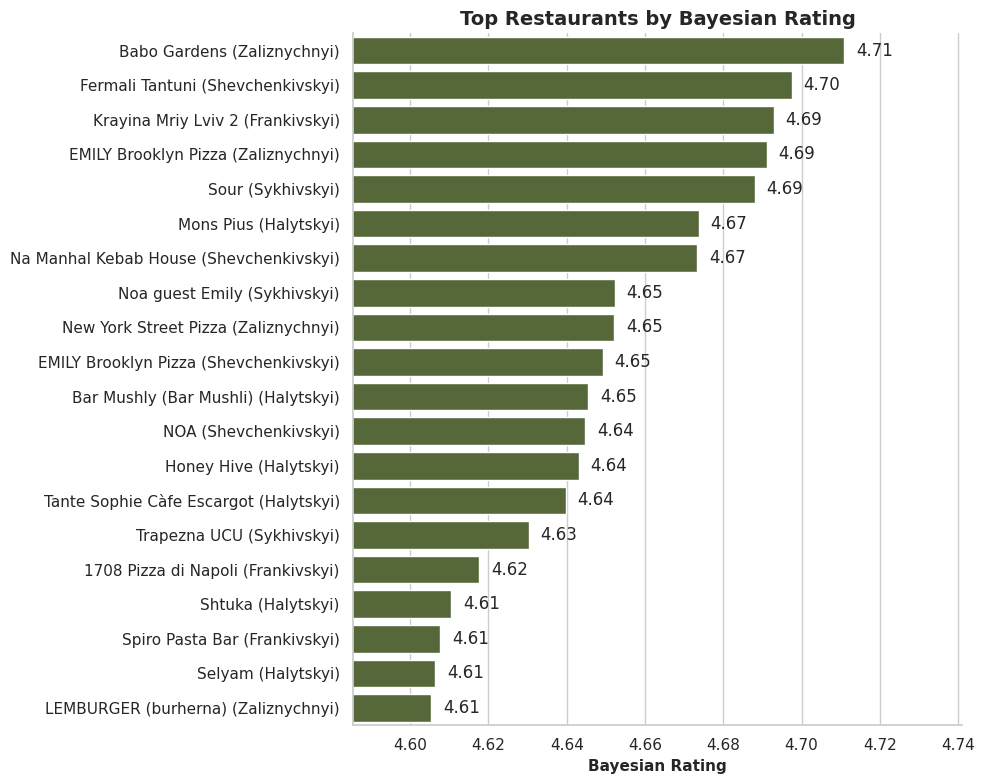

In [48]:
# Top restaurants by Bayesian Rating

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    x=top_restaurants_all["bayesian_rating"],
    y=top_restaurants_all["restaurant_label"],
    color=colors[0],
    errorbar=None
)

for i, v in enumerate(top_restaurants_all["bayesian_rating"]):
    ax.text(v + 0.003, i, f"{v:.2f}", va="center")

plt.title("Top Restaurants by Bayesian Rating", fontsize=14, fontweight="bold")
plt.xlabel("Bayesian Rating", fontsize=11, fontweight="bold")
plt.ylabel("")

plt.xlim(
    top_restaurants_all["bayesian_rating"].min() - 0.02,
    top_restaurants_all["bayesian_rating"].max() + 0.03
)

sns.despine()
plt.tight_layout()
plt.show()

In [49]:
# Bottom restaurants by Bayesian Rating

bottom_restaurants_all = (
    df[df["has_rating"]]
    .sort_values("bayesian_rating")
    [["found_name", "district", "cuisine_type", "business_model", "rating", "bayesian_rating", "reviews_count"]]
    .head(20)
    .copy()
)

bottom_restaurants_all["restaurant_label"] = (
    bottom_restaurants_all["found_name"] + " (" + bottom_restaurants_all["district"] + ")"
)

bottom_restaurants_all

,found_name,district,cuisine_type,business_model,rating,bayesian_rating,reviews_count,restaurant_label
627,Intime bistro,Zaliznychnyi,Bistro,Dine-in Restaurant,2.1,2.822613,966.0,Intime bistro (Zaliznychnyi)
653,Potato House,Frankivskyi,Restaurant (unclassified),Dine-in Restaurant,3.2,3.606513,833.0,Potato House (Frankivskyi)
380,Hotel Tourist Lviv,Frankivskyi,Breakfast | European,Hotel Restaurant,3.2,3.677067,642.0,Hotel Tourist Lviv (Frankivskyi)
264,Sushi Master,Frankivskyi,Sushi,Delivery Only / Dark Kitchen,3.3,3.804116,492.0,Sushi Master (Frankivskyi)
759,Sushyia,Halytskyi,Sushi,Restaurant with Delivery,3.7,3.811168,2202.0,Sushyia (Halytskyi)
345,Emily Resort,Lychakivskyi,Breakfast | European,Hotel Restaurant,3.7,3.868958,1292.0,Emily Resort (Lychakivskyi)
731,Hotel Nton,Shevchenkivskyi,Breakfast | European,Hotel Restaurant,3.7,3.925342,854.0,Hotel Nton (Shevchenkivskyi)
883,I Love Kebab,Shevchenkivskyi,Kebab,Restaurant with Delivery,3.4,3.998911,265.0,I Love Kebab (Shevchenkivskyi)
698,Pizza Celentano,Halytskyi,Pizza,Restaurant with Delivery,3.9,4.015977,1301.0,Pizza Celentano (Halytskyi)
543,Bar B.Q.,Halytskyi,Grill,Dine-in Restaurant,3.9,4.027658,1140.0,Bar B.Q. (Halytskyi)


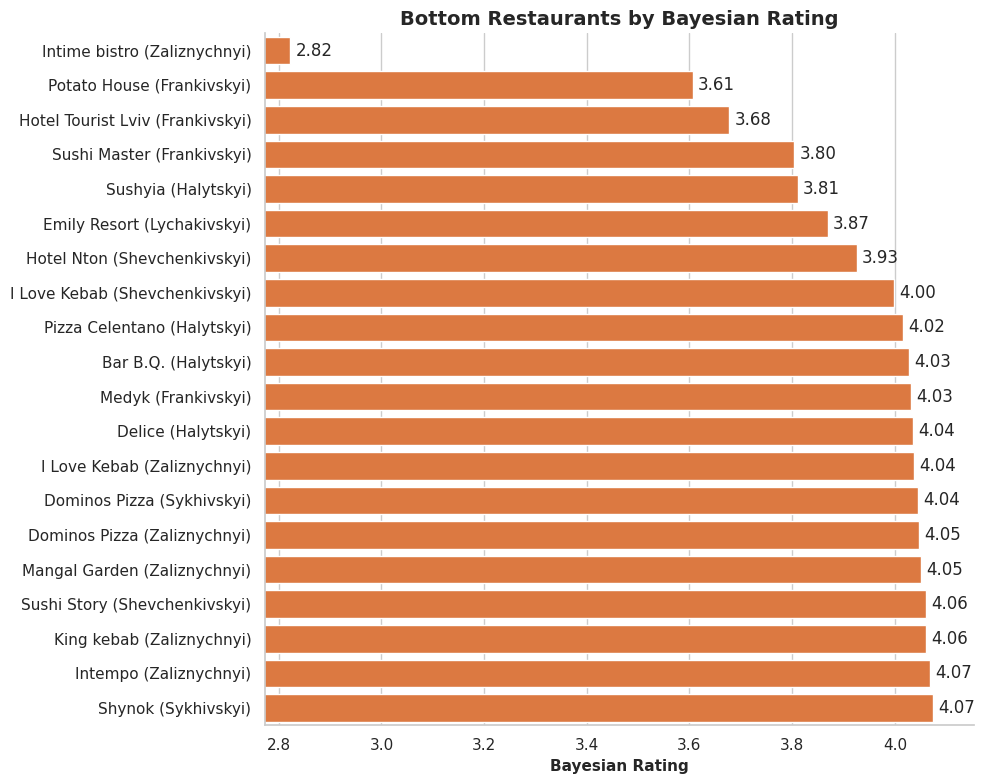

In [50]:
# Bottom restaurants by Bayesian Rating

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    x=bottom_restaurants_all["bayesian_rating"],
    y=bottom_restaurants_all["restaurant_label"],
    color=colors[1],
    errorbar=None
)

for i, v in enumerate(bottom_restaurants_all["bayesian_rating"]):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center")

plt.title("Bottom Restaurants by Bayesian Rating", fontsize=14, fontweight="bold")
plt.xlabel("Bayesian Rating", fontsize=11, fontweight="bold")
plt.ylabel("")

plt.xlim(
    bottom_restaurants_all["bayesian_rating"].min() - 0.05,
    bottom_restaurants_all["bayesian_rating"].max() + 0.08
)

sns.despine()
plt.tight_layout()
plt.show()

**Top and Bottom Restaurant Findings**

The top-ranked restaurants by Bayesian Rating combine high Google Maps ratings with substantial review volume, which makes their reputation more reliable than a simple high-star rating based on a small number of reviews.

**Babo Gardens** has the highest Bayesian Rating in the dataset (**4.71**) with **1,884 reviews**, followed by **Fermali Tantuni (4.70)** and **Krayina Mriy Lviv 2 (4.69)**. Other strong performers include **EMILY Brooklyn Pizza**, **Sour**, **Mons Pius**, and **Na Manhal Kebab House**.

The top list is not dominated by a single cuisine or format. It includes pizza concepts, cafes, kebab/Georgian cuisine, Asian restaurants, burger concepts, and several broader unclassified restaurant formats. This suggests that strong reputation in Lviv is achievable across different restaurant concepts rather than being limited to one specific cuisine category.

Several top-rated restaurants are located outside the historical center. **Zaliznychnyi**, **Frankivskyi**, **Sykhivskyi**, and **Shevchenkivskyi** all appear in the top ranking, confirming that high-performing restaurants are distributed across the city rather than concentrated only in Halytskyi District.

The bottom-ranked restaurants also have meaningful review volumes, so these results are not simply caused by small sample sizes. For example, **Intime bistro** has the lowest Bayesian Rating (**2.82**) with **966 reviews**, while **Sushyia** has a Bayesian Rating of **3.81** based on **2,202 reviews**. This indicates persistent reputation challenges rather than random rating noise.

The lower-ranked group includes several chain or high-traffic formats such as **Sushi Master**, **Sushyia**, **Pizza Celentano**, **Dominos Pizza**, **I Love Kebab**, and hotel restaurant concepts. These formats may face higher customer expectations, stronger competition, or operational consistency challenges.

Overall, Bayesian Rating helps identify both strong market leaders and restaurants with potential reputation risks by combining customer satisfaction with review volume.

*Note: Several top-ranked restaurants are classified as "Restaurant (unclassified)" due to limited cuisine identification during data preparation (see Section 5). Their strong Bayesian Rating performance is still valid, but their cuisine category should not be used for cuisine-level benchmarking.*

## **7. Competitive Positioning**

### **7.1. Cuisine Competition Matrix**

In [51]:
# Cuisine competition matrix

cuisine_competition = cuisine_reputation.copy()

cuisine_competition["competition_level"] = np.where(
    cuisine_competition["restaurants"] >= cuisine_competition["restaurants"].median(),
    "High competition",
    "Low competition"
)

cuisine_competition["reputation_level"] = np.where(
    cuisine_competition["avg_bayesian_rating"] >= cuisine_competition["avg_bayesian_rating"].median(),
    "High reputation",
    "Low reputation"
)

cuisine_competition["positioning"] = (
    cuisine_competition["competition_level"] + " / " + cuisine_competition["reputation_level"]
)

cuisine_competition.sort_values(["competition_level", "avg_bayesian_rating"], ascending=[True, False])

,restaurants,rated_restaurants,avg_rating,avg_bayesian_rating,avg_reviews,median_reviews,rated_share_pct,competition_level,reputation_level,positioning
cuisine_type,,,,,,,,,,
Grill,33,29,4.47,4.40,957.27,230.0,87.9,High competition,High reputation,High competition / High reputation
Georgian,29,26,4.23,4.38,571.00,228.0,89.7,High competition,High reputation,High competition / High reputation
Desserts & Coffee,171,167,4.41,4.37,674.26,220.0,97.7,High competition,High reputation,High competition / High reputation
Pizza,127,120,4.37,4.36,306.86,133.0,94.5,High competition,High reputation,High competition / High reputation
Bakery,86,84,4.35,4.36,515.53,199.5,97.7,High competition,High reputation,High competition / High reputation
Fast Food,44,38,4.29,4.34,1158.70,91.0,86.4,High competition,Low reputation,High competition / Low reputation
Sushi,48,42,4.34,4.34,272.08,74.5,87.5,High competition,Low reputation,High competition / Low reputation
Kebab,106,101,4.21,4.33,214.76,117.5,95.3,High competition,Low reputation,High competition / Low reputation
Bistro,29,26,4.35,4.27,260.03,38.0,89.7,High competition,Low reputation,High competition / Low reputation


In [52]:
positioning_colors = {
    "High competition / High reputation": colors[0],
    "Low competition / High reputation": colors[1],
    "High competition / Low reputation": colors[2],
    "Low competition / Low reputation": colors[3]
}

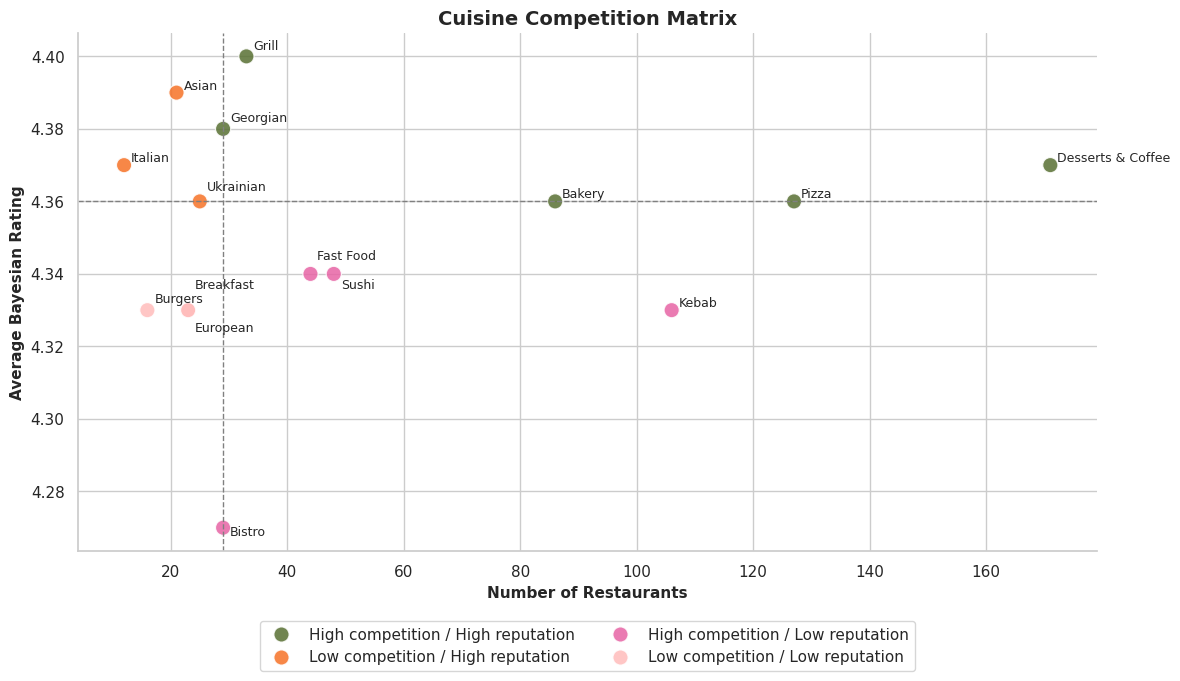

In [53]:
# Cuisine competition matrix

label_offsets = {
    "Fast Food": (1.2, 0.004),
    "Sushi": (1.2, -0.004),
    "Breakfast": (1.2, 0.006),
    "European": (1.2, -0.006),
    "Burgers": (1.2, 0.002),
    "Bistro": (1.2, -0.002),
    "Ukrainian": (1.2, 0.003),
    "Georgian": (1.2, 0.002),
    "Grill": (1.2, 0.002)
}

fig, ax = plt.subplots(figsize=(12, 7))

sns.scatterplot(
    data=cuisine_competition,
    x="restaurants",
    y="avg_bayesian_rating",
    hue="positioning",
    palette=positioning_colors,
    s=120,
    alpha=0.85,
    ax=ax
)

for cuisine, row in cuisine_competition.iterrows():
    x_offset, y_offset = label_offsets.get(cuisine, (1.2, 0.001))
    ax.text(row["restaurants"] + x_offset, row["avg_bayesian_rating"] + y_offset, cuisine, fontsize=9)

ax.axvline(cuisine_competition["restaurants"].median(), color="gray", linestyle="--", linewidth=1)
ax.axhline(cuisine_competition["avg_bayesian_rating"].median(), color="gray", linestyle="--", linewidth=1)

ax.set_title("Cuisine Competition Matrix", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Restaurants", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Bayesian Rating", fontsize=11, fontweight="bold")

ax.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=True
)

sns.despine()
plt.tight_layout()
plt.show()

**Cuisine Competition Matrix Findings**

The matrix helps separate cuisine segments by two dimensions: **market saturation** and **customer reputation**.

The most mature and competitive categories are **Desserts & Coffee**, **Pizza**, and **Bakery**. These segments combine large restaurant supply with above-median Bayesian Rating. This means they are attractive, but also difficult to enter without clear differentiation, because customer expectations are already high and competition is strong.

**Asian**, **Italian**, and **Ukrainian** are the most interesting opportunity segments. They have fewer restaurants than the market median but maintain above-median Bayesian Ratings. This suggests that these cuisines may have room for growth, especially if a new concept can offer strong positioning, consistent quality, and good visibility.

**Kebab**, **Sushi**, and **Fast Food** represent crowded but weaker-performing categories. They have relatively high restaurant presence but lower average Bayesian Ratings, which may indicate price competition, inconsistent quality, or operational challenges. For a new entrant, these segments would require a strong value proposition rather than simply adding another similar concept.

**Bistro** is the weakest category in the matrix, combining below-median reputation with limited scale. This may suggest weaker category positioning or less clearly defined customer expectations.

Overall, the strongest potential opportunities are not in the biggest categories, but in smaller cuisines with already strong reputation signals - especially **Asian, Italian, and Ukrainian**. These segments may offer a better balance between market demand, lower competition, and customer acceptance.

### **7.2. District Competition Matrix**

In [54]:
# District competition matrix

district_competition = df.groupby("district").agg(
    restaurants=("place_id", "nunique"),
    rated_restaurants=("has_rating", "sum"),
    avg_rating=("rating", "mean"),
    avg_bayesian_rating=("bayesian_rating", "mean"),
    avg_reviews=("reviews_count", "mean"),
    median_reviews=("reviews_count", "median")
).round(2)

district_competition["rated_share_pct"] = (
    district_competition["rated_restaurants"] / district_competition["restaurants"] * 100
).round(1)

district_competition["competition_level"] = np.where(
    district_competition["restaurants"] >= district_competition["restaurants"].median(),
    "High competition",
    "Low competition"
)

district_competition["reputation_level"] = np.where(
    district_competition["avg_bayesian_rating"] >= district_competition["avg_bayesian_rating"].median(),
    "High reputation",
    "Low reputation"
)

district_competition["positioning"] = (
    district_competition["competition_level"] + " / " + district_competition["reputation_level"]
)

district_competition.sort_values("restaurants", ascending=False)

,restaurants,rated_restaurants,avg_rating,avg_bayesian_rating,avg_reviews,median_reviews,rated_share_pct,competition_level,reputation_level,positioning
district,,,,,,,,,,
Frankivskyi,208,194,4.33,4.35,354.84,97.0,93.3,High competition,Low reputation,High competition / Low reputation
Sykhivskyi,182,163,4.36,4.36,280.45,104.5,89.6,High competition,High reputation,High competition / High reputation
Shevchenkivskyi,153,136,4.33,4.36,329.80,115.0,88.9,High competition,High reputation,High competition / High reputation
Zaliznychnyi,149,140,4.32,4.34,389.56,133.0,94.0,Low competition,Low reputation,Low competition / Low reputation
Halytskyi,138,134,4.37,4.40,1758.31,774.5,97.1,Low competition,High reputation,Low competition / High reputation
Lychakivskyi,104,94,4.37,4.36,399.80,90.0,90.4,Low competition,High reputation,Low competition / High reputation


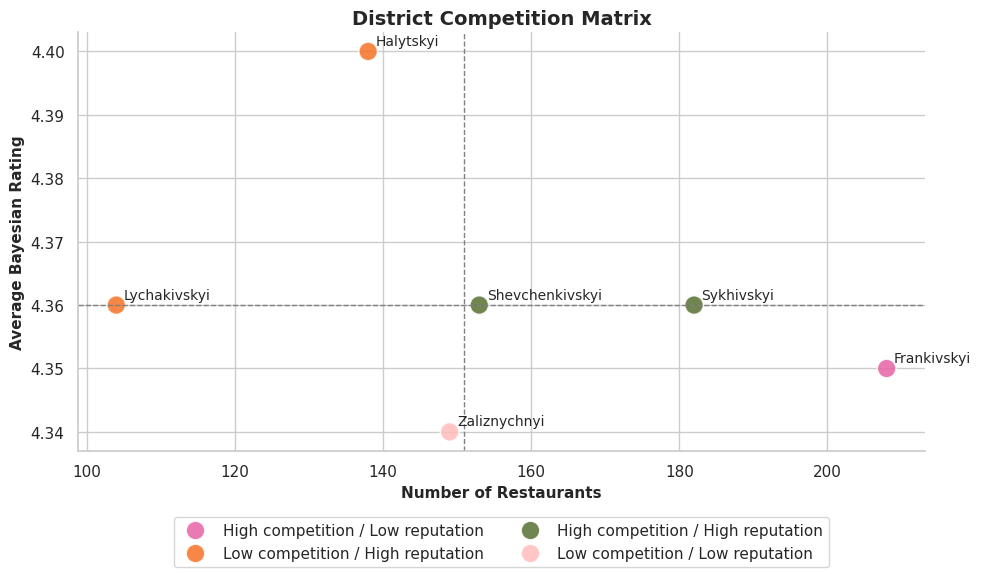

In [55]:
# District competition matrix

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=district_competition,
    x="restaurants",
    y="avg_bayesian_rating",
    hue="positioning",
    palette=positioning_colors,
    s=180,
    alpha=0.85,
    ax=ax
)

for district, row in district_competition.iterrows():
    ax.text(
        row["restaurants"] + 1,
        row["avg_bayesian_rating"] + 0.001,
        district,
        fontsize=10
    )

ax.axvline(district_competition["restaurants"].median(), color="gray", linestyle="--", linewidth=1)
ax.axhline(district_competition["avg_bayesian_rating"].median(), color="gray", linestyle="--", linewidth=1)

ax.set_title("District Competition Matrix", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Restaurants", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Bayesian Rating", fontsize=11, fontweight="bold")

ax.legend(
    title="",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=2,
    frameon=True
)

sns.despine()
plt.tight_layout()
plt.show()

**District Competition Matrix Findings**

District-level differences are more subtle than cuisine-level differences. Average Bayesian Ratings across districts range only from **4.34 to 4.40**, which means that restaurant reputation is generally strong across the city and no district clearly underperforms.

The main difference between districts is not rating quality, but **market scale and customer visibility**.

**Frankivskyi** is the largest restaurant district with **208 restaurants**, but its average Bayesian Rating falls just below the six-district median (**4.35**), placing it in the "High competition / Low reputation" quadrant. This suggests that it is a large and competitive market where simply entering the district may not be enough — differentiation by cuisine, format, price, or service model would be important.

**Halytskyi** stands out less by restaurant count and more by customer engagement. It has the highest average Bayesian Rating (**4.40**) and by far the highest average review volume (**1,758 reviews per restaurant**). This indicates a high-visibility environment where restaurants receive much more customer feedback, likely due to central location, tourism, and higher foot traffic.

**Sykhivskyi** and **Shevchenkivskyi** combine relatively large restaurant supply with stable reputation levels. These districts look like balanced competitive markets: large enough to indicate demand, but without the extreme review concentration seen in Halytskyi.

**Lychakivskyi** has the smallest restaurant base (**104 restaurants**) but maintains an above-median Bayesian Rating (**4.36**). This may indicate a smaller but healthy local market rather than a major expansion hotspot.

**Zaliznychnyi** has a moderate restaurant base (**149 restaurants**) and the lowest average Bayesian Rating (**4.34**). Since the difference is small, this should not be interpreted as a weak district, but it may point to more room for quality differentiation compared with other areas.

Overall, the district matrix is most useful for understanding **market context** rather than selecting a single “best” district. Halytskyi appears strongest for visibility and review volume, Frankivskyi offers the largest market size, while Sykhivskyi and Shevchenkivskyi provide a more balanced combination of scale and reputation.

### **Competitive Positioning Summary**

The competitive positioning analysis shows that cuisine-level differences are more informative than district-level differences.

Cuisine categories vary more clearly by market size and reputation. Large segments such as **Desserts & Coffee**, **Pizza**, and **Bakery** represent mature and competitive categories with strong customer reputation, while **Asian**, **Italian**, and **Ukrainian** appear as smaller but well-rated segments with potentially stronger positioning opportunities.

District-level differences are more subtle. Average Bayesian Ratings across districts are very close, which suggests that districts differ more by market scale and customer visibility than by restaurant quality.

Overall, competitive opportunities should be evaluated through a combination of **cuisine choice**, **district context**, and **service model**, rather than by relying on a single metric.

## **8. Marketplace Presence**

### **8.1. Glovo Presence by District**

In [56]:
# Glovo restaurants by district

glovo_district = df[df["glovo_available"]]["district"].value_counts().to_frame("glovo_restaurants")

glovo_district["share_pct"] = (
    glovo_district["glovo_restaurants"] / df["glovo_available"].sum() * 100
).round(2)

glovo_district

,glovo_restaurants,share_pct
district,,
Frankivskyi,64,25.6
Sykhivskyi,52,20.8
Zaliznychnyi,52,20.8
Shevchenkivskyi,39,15.6
Halytskyi,22,8.8
Lychakivskyi,21,8.4


In [57]:
# Glovo presence by district

districts = df["district"].value_counts()
glovo = df[df["glovo_available"]]["district"].value_counts().reindex(districts.index)

glovo_penetration = pd.DataFrame({
    "restaurants": districts,
    "glovo_restaurants": glovo
})

glovo_penetration["glovo_share_pct"] = (
    glovo_penetration["glovo_restaurants"] / glovo_penetration["restaurants"] * 100
).round(2)

glovo_penetration = glovo_penetration.sort_values("glovo_share_pct", ascending=False)

glovo_penetration

,restaurants,glovo_restaurants,glovo_share_pct
district,,,
Zaliznychnyi,149,52,34.90
Frankivskyi,208,64,30.77
Sykhivskyi,182,52,28.57
Shevchenkivskyi,153,39,25.49
Lychakivskyi,104,21,20.19
Halytskyi,138,22,15.94


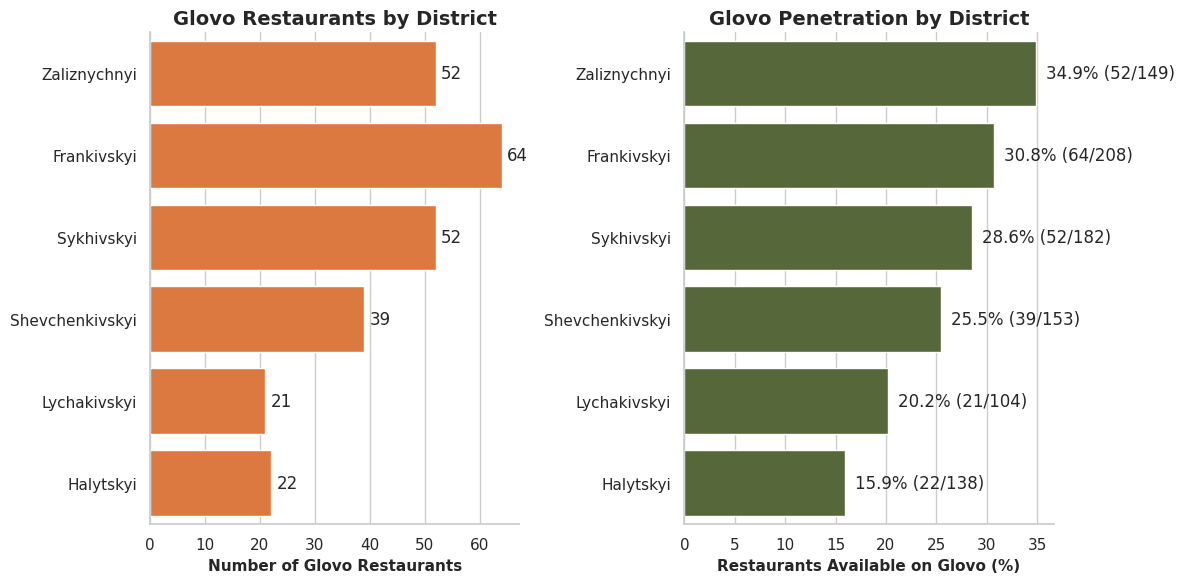

In [58]:
# Glovo restaurants and penetration by district

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.barplot(
    x=glovo_penetration["glovo_restaurants"],
    y=glovo_penetration.index,
    color=colors[1],
    ax=axes[0]
)

sns.barplot(
    x=glovo_penetration["glovo_share_pct"],
    y=glovo_penetration.index,
    color=colors[0],
    ax=axes[1]
)

for i, row in enumerate(glovo_penetration.itertuples()):
    axes[0].text(
        row.glovo_restaurants + 1,
        i,
        int(row.glovo_restaurants),
        va="center"
    )

    axes[1].text(
        row.glovo_share_pct + 1,
        i,
        f"{row.glovo_share_pct:.1f}% ({row.glovo_restaurants}/{row.restaurants})",
        va="center"
    )

axes[0].set_title("Glovo Restaurants by District", fontsize=14, fontweight="bold")
axes[1].set_title("Glovo Penetration by District", fontsize=14, fontweight="bold")

axes[0].set_xlabel("Number of Glovo Restaurants", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Restaurants Available on Glovo (%)", fontsize=11, fontweight="bold")

for ax in axes:
    ax.set_ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

**Glovo Presence by District Findings**

Glovo presence varies across Lviv districts both in absolute scale and in relative platform penetration.

**Frankivskyi** has the largest number of Glovo restaurants, with **64 restaurants** available on the platform. This reflects its position as the largest restaurant district overall and confirms its importance as a major marketplace area.

However, the highest relative Glovo penetration is observed in **Zaliznychnyi**, where **52 out of 149 restaurants** are available on Glovo, resulting in **34.9% platform penetration**. This means that Zaliznychnyi has the strongest relative Glovo coverage compared with its total restaurant base.

**Sykhivskyi** also shows strong marketplace presence, with **52 Glovo restaurants** and **28.6% penetration**. Together with Frankivskyi and Zaliznychnyi, it forms one of the key districts for Glovo supply.

**Halytskyi** has the lowest Glovo penetration, with only **22 out of 138 restaurants** available on the platform (**15.9%**). This is notable because Halytskyi is the historical and tourist-oriented city center. Its lower Glovo presence may indicate stronger reliance on dine-in traffic, offline visibility, direct ordering, or other delivery channels.

Overall, Glovo presence is not simply proportional to the total number of restaurants in each district. Some districts, especially **Zaliznychnyi**, show stronger platform adoption relative to their restaurant base, while central districts such as **Halytskyi** are less represented on Glovo.

### **8.2. Glovo Availability by Cuisine**

In [59]:
# Glovo availability by cuisine

cuisine_glovo = (
    cuisine_exploded[cuisine_exploded["cuisine_type"].isin(cuisine_market.index)]
    .groupby("cuisine_type")
    .agg(
        restaurants=("place_id", "nunique"),
        glovo_restaurants=("glovo_available", "sum")
    )
)

cuisine_glovo["glovo_share_pct"] = (
    cuisine_glovo["glovo_restaurants"] / cuisine_glovo["restaurants"] * 100
).round(2)

cuisine_glovo = cuisine_glovo.sort_values("glovo_share_pct", ascending=False)

cuisine_glovo

,restaurants,glovo_restaurants,glovo_share_pct
cuisine_type,,,
American,3,2,66.67
Pizza,127,84,66.14
Burgers,16,9,56.25
International,6,3,50.00
Bakery,86,42,48.84
Kebab,106,49,46.23
Fast Food,44,17,38.64
Asian,21,8,38.10
Desserts & Coffee,171,62,36.26


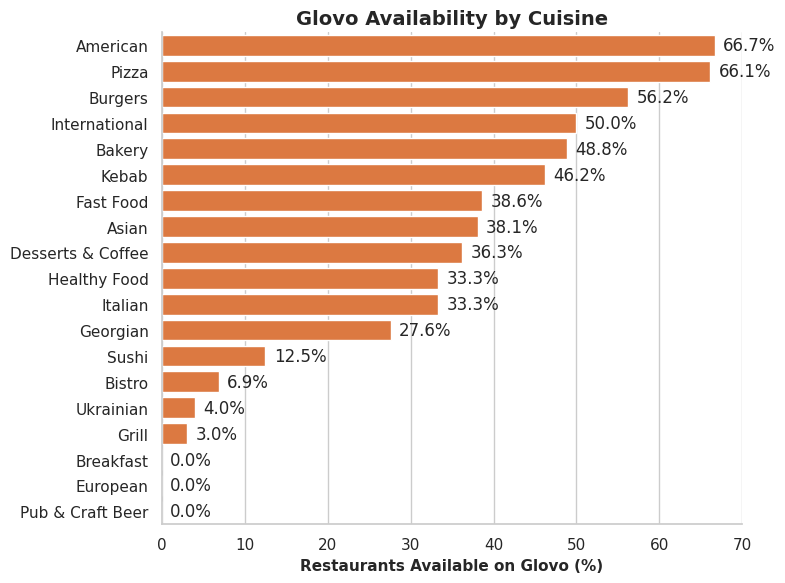

In [60]:
# Glovo availability by cuisine

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=cuisine_glovo["glovo_share_pct"],
    y=cuisine_glovo.index,
    color=colors[1]
)

for i, v in enumerate(cuisine_glovo["glovo_share_pct"]):
    ax.text(v + 1, i, f"{v:.1f}%", va="center")

plt.title("Glovo Availability by Cuisine", fontsize=14, fontweight="bold")
plt.xlabel("Restaurants Available on Glovo (%)", fontsize=11, fontweight="bold")
plt.ylabel("")

sns.despine()
plt.tight_layout()
plt.show()

**Glovo Availability by Cuisine Findings**

Glovo availability varies strongly across cuisine categories, but it should be interpreted specifically as **presence on the Glovo platform**, not as total delivery availability.

Restaurants that are not available on Glovo may still offer delivery through other channels, such as direct ordering, phone orders, their own websites, Bolt Food, or other local delivery services.

**Pizza** is the strongest large-scale Glovo category: **84 out of 127 pizza restaurants** are available on Glovo, resulting in **66.1% platform penetration**. This confirms that pizza is one of the most Glovo-oriented cuisine segments in the dataset.

**Kebab** also shows strong Glovo presence, with **49 out of 106 restaurants** available on the platform (**46.2%**). Together with Pizza, this highlights the importance of convenient, high-frequency, delivery-friendly food categories within marketplace supply.

**Bakery** has relatively high Glovo availability at **48.8%**, with **42 out of 86 restaurants** present on the platform. This suggests that bakery products may have a stronger fit for platform-based ordering than expected, especially for quick orders, snacks, and breakfast-related demand.

**Desserts & Coffee** is the largest cuisine category overall, but its Glovo penetration is lower at **36.3%**. This indicates that while the segment is highly present across the city, many cafes and dessert-oriented venues may rely more on offline traffic, takeaway, direct ordering, or other delivery channels.

Some categories have high percentages but small restaurant bases. For example, **American** shows **66.7%** Glovo availability, but this is based on only **3 restaurants**, so it should be interpreted cautiously.

Traditional or experience-oriented categories show much weaker Glovo presence. **Ukrainian (4.0%)**, **Grill (3.0%)**, **Breakfast (0.0%)**, **European (0.0%)**, and **Pub & Craft Beer (0.0%)** are largely absent from Glovo. This does not necessarily mean they do not deliver; rather, they are underrepresented specifically on this marketplace platform.

Overall, Glovo presence is strongest in scalable, standardized, and marketplace-friendly categories such as **Pizza, Burgers, Bakery, Kebab, and Fast Food**, while more traditional or experience-driven cuisines are less visible on Glovo and may rely more on offline demand or alternative delivery channels.

## **9. Key Insights**

**1. The Lviv restaurant market is large, mature, and delivery-oriented**

With **934 restaurants** across **46 original cuisine classifications** and **8 business models**, the market shows strong customer engagement (average Bayesian Rating **4.36**) and widespread delivery adoption (**67.1%**). This signals a mature, competitive ecosystem rather than an emerging or underdeveloped market.

**2. Cuisine presence is concentrated in a few dominant categories**

**Desserts & Coffee** (171), **Pizza** (127), **Kebab** (106), and **Bakery** (86) account for over half of all classified restaurant presence. The top **13 cuisine categories** cover more than **80%** of classified cuisine presence, while the remaining cuisine categories form a long tail of smaller and more niche segments.

**3. District distribution is relatively balanced, with no single center of gravity**

**Frankivskyi** (22.3%), **Sykhivskyi** (19.5%), and **Shevchenkivskyi** (16.4%) lead in restaurant count, but **Halytskyi** - the historical city center - accounts for only **14.8%**. This confirms that restaurant demand in Lviv is distributed across residential and commercial districts, not concentrated solely downtown.

**4. Operating hours create an additional layer of restaurant accessibility**

Operating hours were successfully parsed for **845 restaurants (90.5%)**, making schedule availability reliable enough for market-level comparison. The typical restaurant in Lviv operates for around **12 hours per day**, with a median daily opening duration of **12.0 hours**. Most restaurants open between **9:00 and 11:00** and close between **20:00 and 22:00**, while only **4.3%** operate up to 8 hours per day. Sunday closure is also relatively uncommon, with only **7.9%** of restaurants explicitly marked as closed on Sunday. This makes operating schedule an important factor for benchmarking individual restaurants with limited hours or regular weekend closures.

**5. Bayesian Rating reveals reputation patterns that raw rating cannot**

Raw Google Maps rating shows almost no correlation with review volume (**r=0.06**), making it unreliable for comparing restaurants with different visibility levels. **Bayesian Rating** corrects for this, providing a more stable basis for benchmarking - including for any restaurant being compared against this market later.

**6. Market saturation and reputation are independent dimensions**

The Cuisine Competition Matrix shows that high restaurant count does not guarantee high reputation (**Kebab, Sushi, Fast Food**: crowded but below-median rating), while several smaller cuisines (**Asian, Italian, Ukrainian**) combine low competition with above-median reputation - a more favorable competitive position.

**7. Delivery adoption far exceeds Glovo marketplace presence**

**67.1%** of restaurants offer delivery, but only **26.8%** are identified as available on Glovo in this dataset. This **40-point gap** indicates that a large share of delivery-enabled restaurants operate outside Glovo, potentially through direct ordering, alternative platforms, phone orders, or restaurant-operated channels.

**8. Glovo presence is cuisine-dependent, not market-wide**

**Pizza** (66.1%), **Burgers** (56.2%), and **Bakery** (48.8%) show strong Glovo penetration, while traditional or experience-driven cuisines like **Ukrainian** (4.0%), **Grill** (3.0%), and **European** (0.0%) are nearly absent from the platform. This means Glovo presence reflects cuisine fit for delivery, not overall market importance.

**9. Growth opportunities exist where competition is low and reputation is high**

**Asian, Italian,** and **Ukrainian** cuisines stand out as the most promising opportunity segments - they combine below-median restaurant count with above-median Bayesian Rating, suggesting room for new concepts without facing the intense competition seen in Desserts & Coffee, Pizza, or Kebab.

---


## **10. Business Recommendations**

**1. Use this market structure as the baseline for restaurant-level benchmarking**

Any individual restaurant analyzed against the Lviv market should be positioned against **cuisine-specific medians** (rating, review volume, district norms) established here - not market-wide averages, which can mask meaningful differences between segments.

**2. Treat cuisine choice as a competitive positioning decision, not just a menu decision**

A new restaurant or delivery concept entering Lviv should evaluate cuisine selection through the **Competition Matrix** lens: crowded-but-strong categories (**Pizza, Bakery**) require differentiation to compete, while crowded-but-weak categories (**Kebab, Sushi, Fast Food**) require a clear value proposition to stand out from already-saturated, inconsistent competition.

**3. Prioritize Asian, Italian, and Ukrainian cuisines as promising opportunity segments**

These segments may offer a more balanced opportunity profile for a new concept seeking demand validation without immediate exposure to the most saturated categories.

**4. Don't assume district choice alone drives success**

Since reputation differences across districts are small (**4.34-4.40**) compared to cuisine differences, district selection should be treated as a **secondary decision** - focused on target customer proximity and visibility (e.g. Halytskyi for tourist foot traffic) rather than as the primary lever for competitive advantage.

**5. Include operating schedule in restaurant-level benchmarking**

When comparing an individual restaurant against the Lviv market, operating hours should be treated as part of competitive accessibility. The market norm is approximately **12 hours of operation per day**, with most restaurants opening around **9:00-10:00** and closing around **21:00-22:00**. A restaurant that operates fewer hours, closes earlier than competitors, or is closed on Sunday may lose potential demand during standard market availability windows.

**6. Recognize that Glovo presence is not synonymous with market relevance**

A restaurant evaluating delivery platform strategy should note that some well-rated cuisines, including **Ukrainian, Grill, and European**, operate largely outside Glovo in this dataset. Marketplace absence does not necessarily imply weak demand - it may reflect cuisine-specific reliance on dine-in experience, direct ordering, offline visibility, or alternative delivery channels.

**7. Match platform strategy to cuisine type**

Restaurants in scalable, standardized categories such as **Pizza, Burgers, Bakery, and Fast Food** should strongly consider Glovo as part of their delivery strategy, since these are the categories where platform presence is most concentrated. Restaurants in traditional or experience-oriented cuisines should evaluate Glovo investment more carefully, since platform fit appears weaker for these segments based on current market behavior.

---


## **Final Conclusion**

This notebook analyzed the **Lviv restaurant market** using data collected from Google Maps, enriched with district classification, cuisine segmentation, business model categorization, and **Bayesian Rating**. Across **934 restaurants**, the analysis addressed each of the original business questions: market size and diversity, cuisine dominance, district distribution, business model structure, rating reliability, delivery penetration, and where competitive opportunities may exist.

The market is **mature and delivery-oriented**, with two-thirds of restaurants offering delivery and a **Restaurant-with-Delivery** business model leading at **43.5%** of supply. Cuisine presence is **moderately concentrated**, with four categories - **Desserts & Coffee, Pizza, Kebab,** and **Bakery** - accounting for over half of classified cuisine presence, while a long tail of smaller cuisines adds diversity without significant market share.

**Restaurant reputation** across Lviv is consistently strong, but raw rating proved unreliable for comparison due to its weak relationship with review volume. **Bayesian Rating** addressed this limitation and became the foundation for all subsequent competitive analysis - confirming that reputation and market saturation are largely independent dimensions, with several smaller cuisines (**Asian, Italian, Ukrainian**) offering a more favorable balance of demand and quality than the largest, most saturated categories.

Operating hours added an additional operational dimension to the market baseline. Most restaurants with parsed schedules operate for around **12 hours per day**, typically opening between **9:00 and 11:00** and closing between **20:00 and 22:00**. Regular Sunday closure is relatively uncommon, which makes schedule availability an important factor for later benchmarking of individual restaurants with shorter working hours or weekend closures.

Finally, the gap between **delivery adoption (67%)** and **Glovo presence (27%)** revealed that a large share of delivery-enabled restaurants operate outside Glovo, and that this gap varies significantly by cuisine and district rather than applying uniformly across the market.

This notebook establishes the **market-level foundation** for the project. The next stage will examine the **Glovo marketplace** specifically - including menu structure, pricing, and promotional strategy - before benchmarking an individual restaurant's performance against the patterns identified here.